# Partie I : Partitionnement Hiérarchique Ascendant

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## Quelques données simulées

Considérons quelques données pour étudier le comportement de diverses notions de dissimilarité entre groupes.

#### 1. Pour ce premier exercice, nous allons réutiliser les données du TD sur l'algorithme des k-moyennes. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier des groupes dans ces données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`, et `average`.

In [138]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import prince
data = pd.read_csv("Advertising.csv", sep=",")

scaler = StandardScaler()
new_data = scaler.fit_transform(data)
new_data = pd.DataFrame(new_data, columns=data.columns)
new_data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,-1.723412,0.969852,0.981522,1.778945,1.552053
1,-1.706091,-1.197376,1.082808,0.669579,-0.696046
2,-1.688771,-1.516155,1.528463,1.783549,-0.907406
3,-1.671450,0.052050,1.217855,1.286405,0.860330
4,-1.654129,0.394182,-0.841614,1.281802,-0.215683


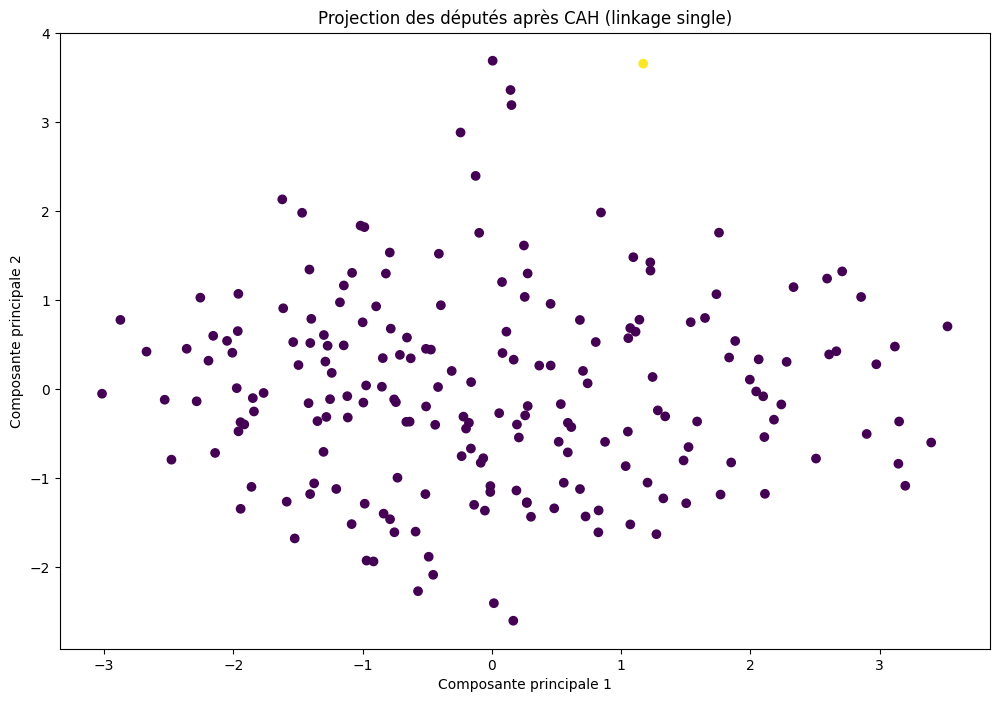

In [139]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2) # je veux projeter sur 2 dimensions

# Projection des individus
data_pca = pca.fit_transform(new_data) # on utilise les données standardisées
data_pca = pd.DataFrame(data_pca, columns=["axe1", "axe2"]) # je crée un DataFrame pour plus de facilité

model_single = AgglomerativeClustering(linkage='single')
model_single_labels = model_single.fit_predict(new_data)

plt.scatter(data_pca["axe1"], data_pca["axe2"], c=model_single_labels) # on colorie selon les clusters trouvés
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des députés après CAH (linkage single)")
plt.show()



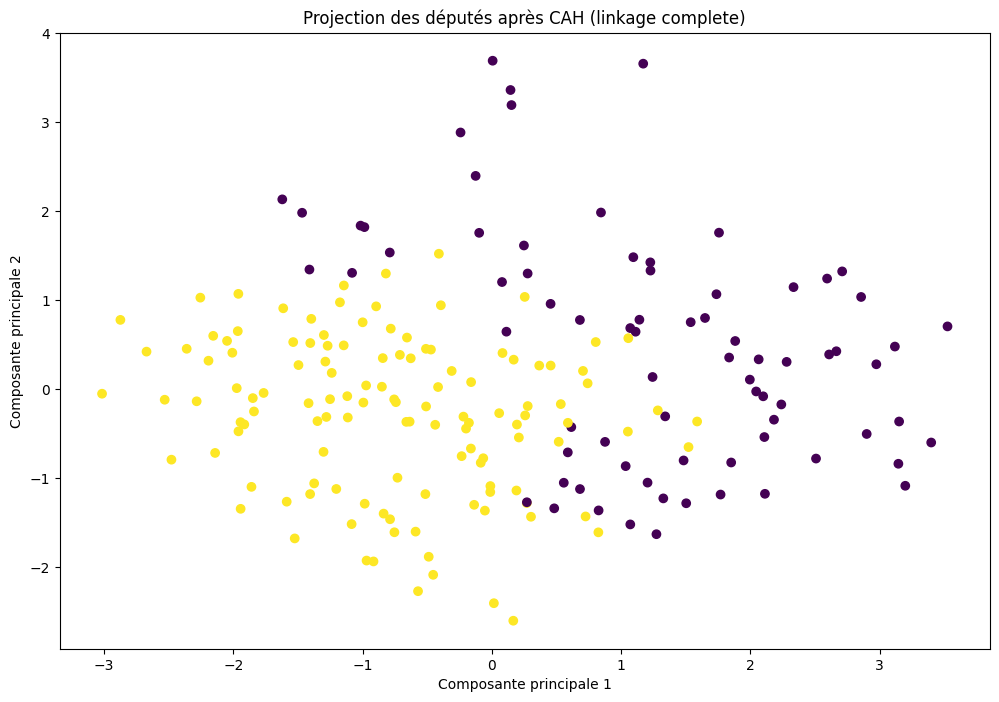

In [140]:
model_complete = AgglomerativeClustering(linkage='complete')
model_complete_labels = model_complete.fit_predict(new_data)

plt.scatter(data_pca["axe1"], data_pca["axe2"], c=model_complete_labels) # on colorie selon les clusters trouvés
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des députés après CAH (linkage complete)")
plt.show()

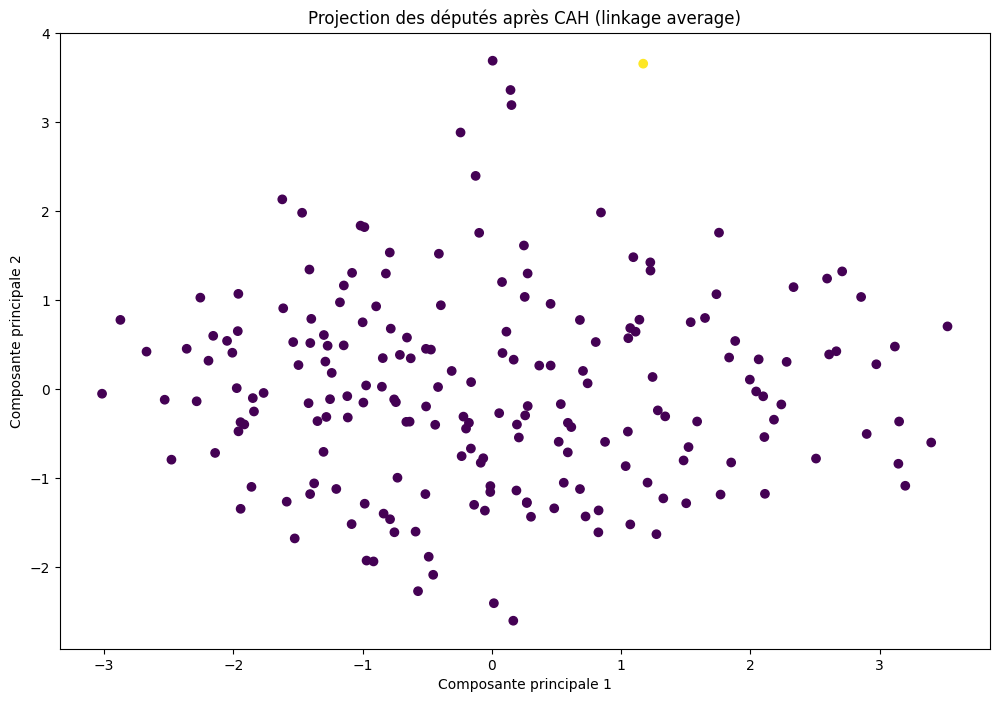

In [141]:
model_average = AgglomerativeClustering(linkage='average')
model_average_labels = model_average.fit_predict(new_data)

plt.scatter(data_pca["axe1"], data_pca["axe2"], c=model_average_labels) # on colorie selon les clusters trouvés
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des députés après CAH (linkage average)")
plt.show()

#### 2. Visualisez le résultat obtenu. Quel méthode semble obtenir les meilleurs groupes ?

Considérez maintenant les données générées ci-après.

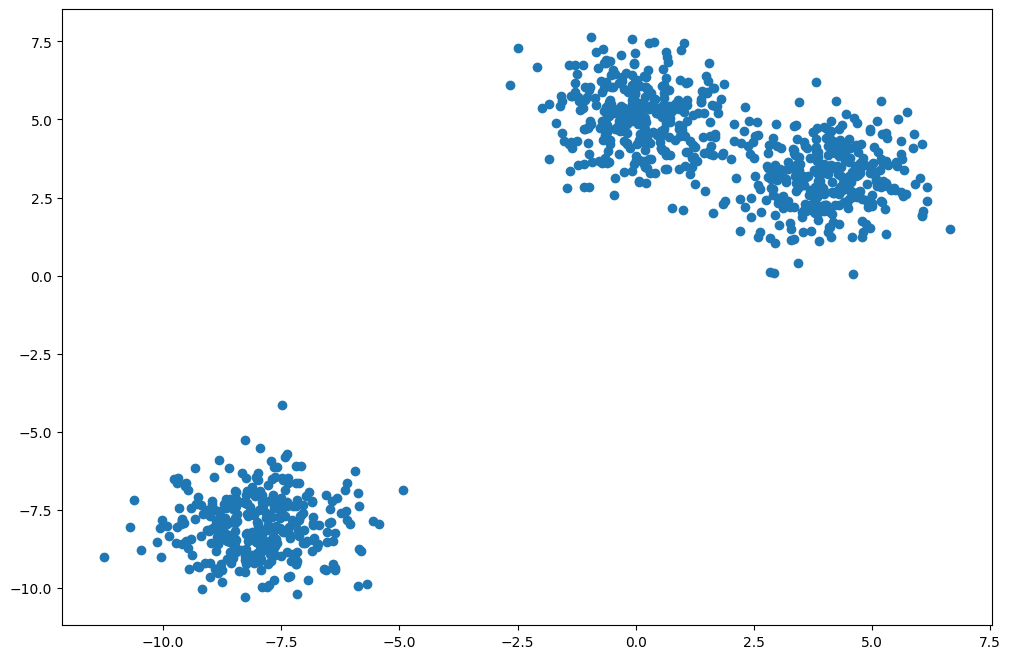

In [142]:
from sklearn.datasets import make_blobs
m = 1000
blobs_X,_ = make_blobs(m,centers=[[-8,-8],[0,5],[4,3]],random_state=42)   

plt.scatter(blobs_X[:,0],blobs_X[:,1])

## Dataset MNIST

#### 3. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier le nombre de groupes qui vous semble le plus adéquat dans ces nouvelles données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`,  `ward` et `average`. Visualisez le résultat. Que pouvez-vous en conclure ?

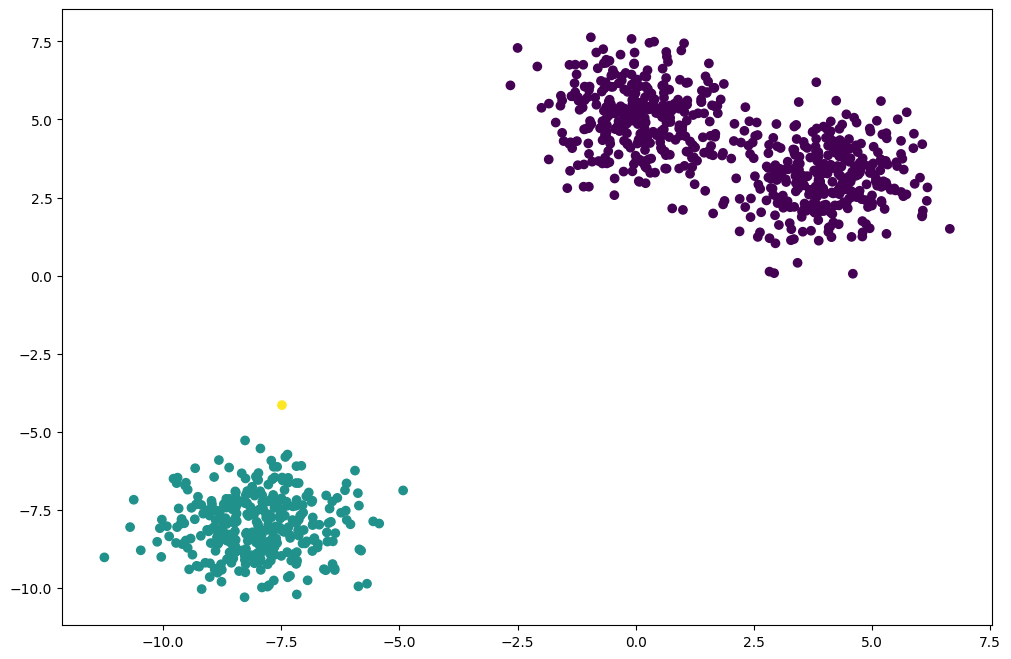

In [143]:
# methode avec single
mod_single = AgglomerativeClustering(n_clusters=3, linkage='single')
blobs_groups = mod_single.fit_predict(blobs_X)
plt.scatter(blobs_X[:,0],blobs_X[:,1],c=blobs_groups)

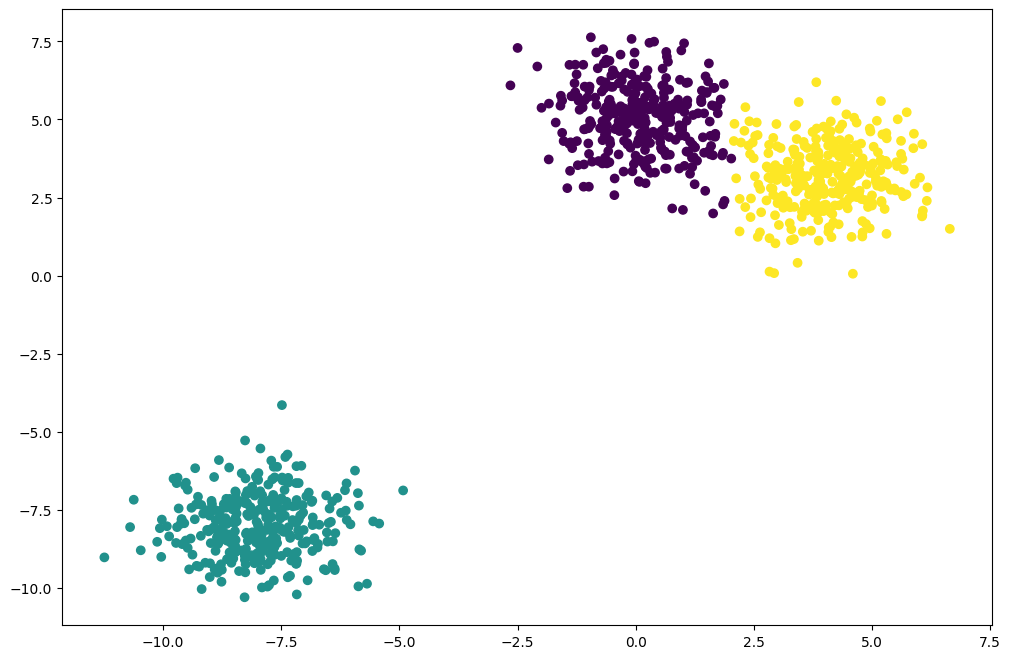

In [144]:
# methode avec complete
mod_complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
blobs_groups = mod_complete.fit_predict(blobs_X)
plt.scatter(blobs_X[:,0],blobs_X[:,1],c=blobs_groups)

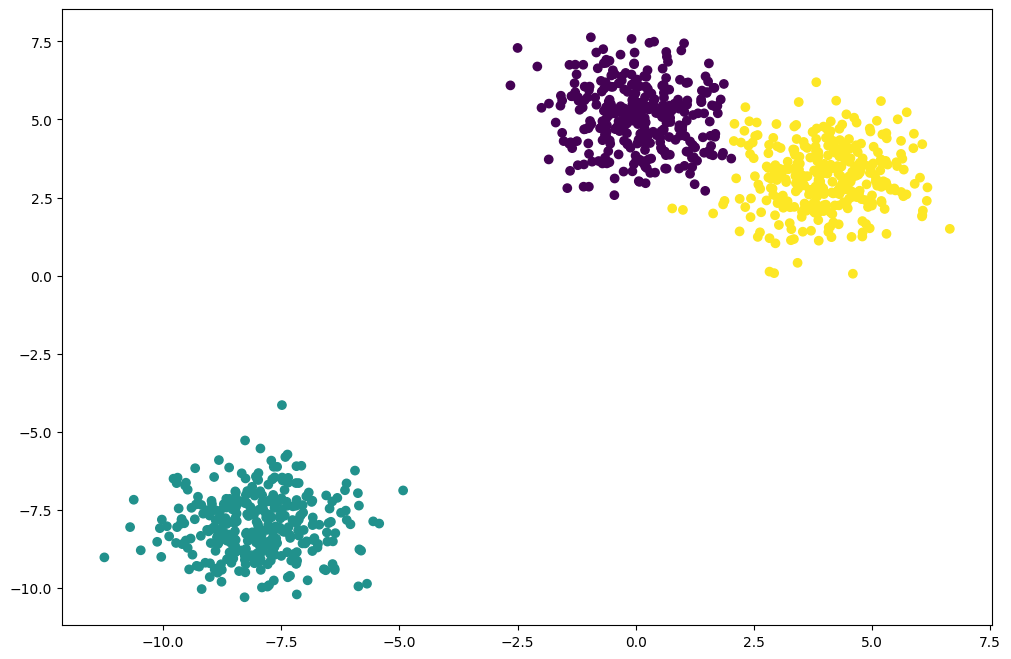

In [145]:
# methode avec average
mod_average = AgglomerativeClustering(n_clusters=3, linkage='average')
blobs_groups = mod_average.fit_predict(blobs_X)
plt.scatter(blobs_X[:,0],blobs_X[:,1],c=blobs_groups)

contrairement à l'étape précédente, ici nous constation que la méthode complete semble plus réaliste bienvraie que la méthode average a aussi proposée une bonne répartition.

Nous allons maintenant nous intéresser au dataset MNIST.

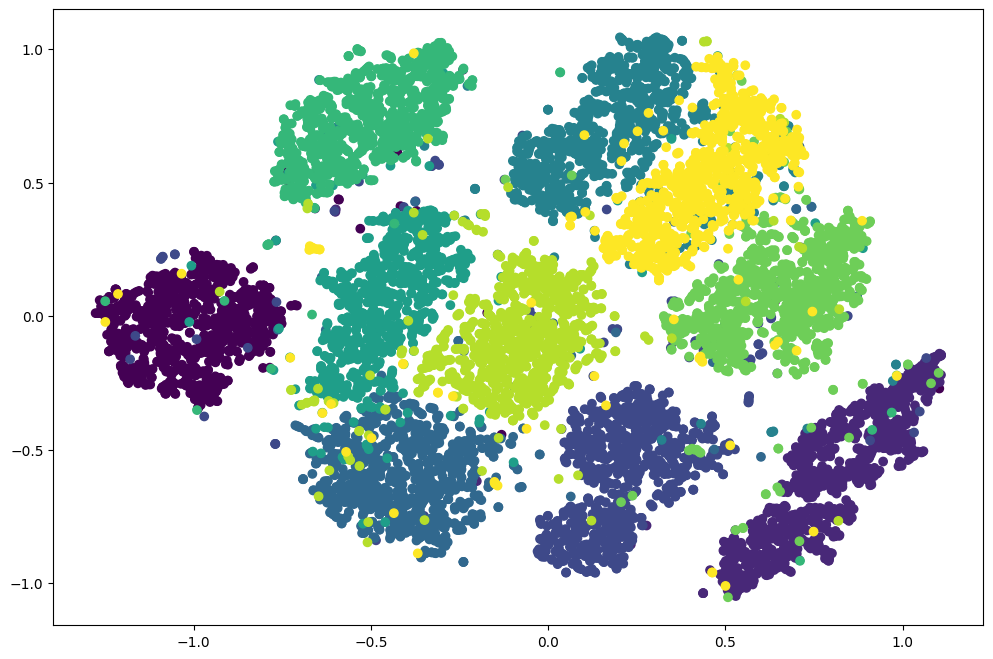

In [146]:
mnist_X = pd.read_csv("../MNIST-20260105/mnist_data.csv")/100
mnist_y = pd.read_csv("../MNIST-20260105/mnist_labels.csv",dtype=int).squeeze()
plt.scatter(mnist_X["tSNE1"],mnist_X["tSNE2"],c=mnist_y)

#### 4. Utilisez `sklearn.cluster.AgglomerativeClustering` pour identifier 10 groupes dans ces données. Vous considérerez tour à tour les fonctions de dissimilarité entres groupes `single`, `complete`, `ward` et `average`. 

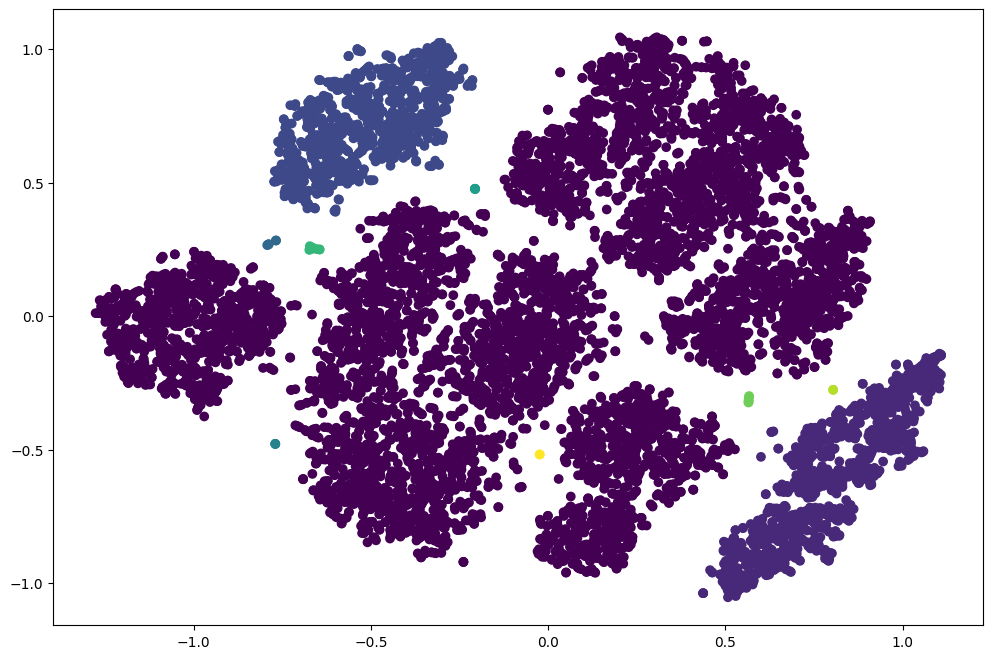

In [147]:
# modèle avec single
mod_single = AgglomerativeClustering(n_clusters=10, linkage='single')
labels = mod_single.fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=labels)

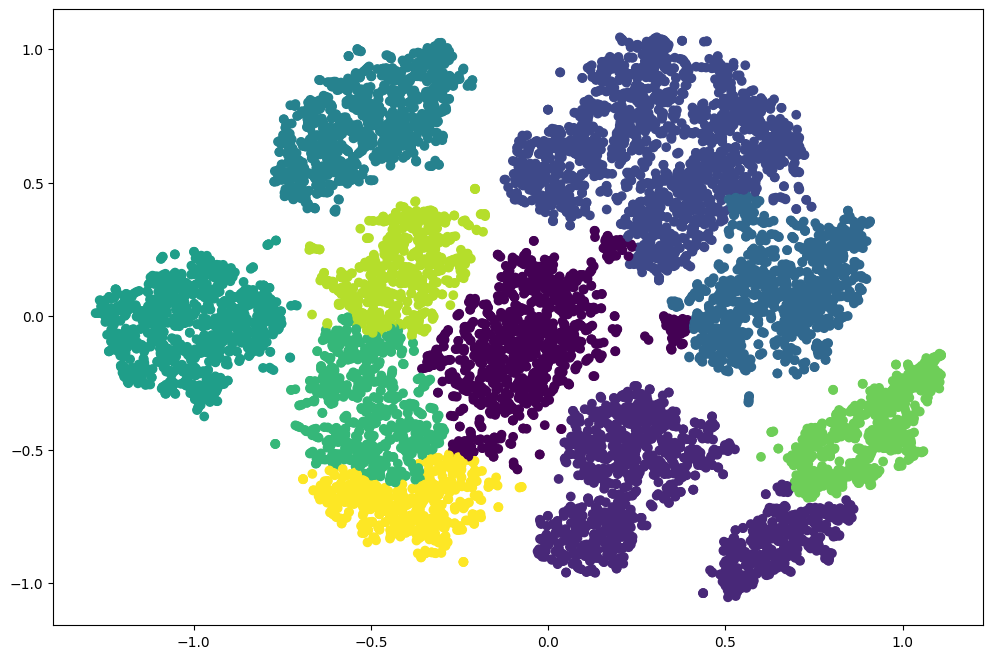

In [148]:
# modèle avec complete
mod_complete = AgglomerativeClustering(n_clusters=10, linkage='complete')
labels = mod_complete.fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=labels)

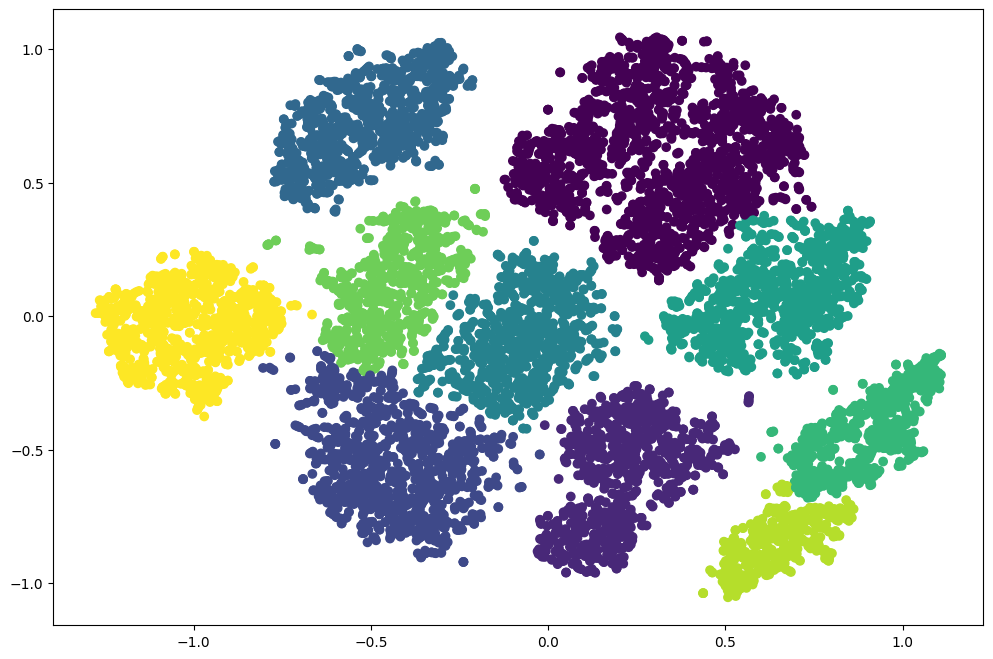

In [149]:
# modèle avec average
mod_average = AgglomerativeClustering(n_clusters=10, linkage='average')
labels = mod_average.fit_predict(X)
plt.scatter(X["tSNE1"],X["tSNE2"],c=labels)

#### 5. Visualisez les résultats. Que constatez vous ?

D'après les représentations des différents modèles, nous constatons que la méthode avec linkage = 'average' semble obtenir les meilleurs groupes. Mais aussi force est de constater que la segmentation proposée par la méthode complete reste qu'à meme acceptable.

## Dendrogrammes

Lorsque le nombre de groupes à découvrir n'est pas spécifié (on initialise l'algorithme avec les paramètres `distance_threshold=0` et `n_clusters=None`). Il est possible d'afficher le dendrogramme qui donne l'ordre de formation des différents groupes.

#### 6. Inspirez-vous du code fournit sur la page `https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html` pour afficher le dendrogramme obtenu sur les données MNIST par l'approche par `average linkage`.

In [150]:
from scipy.cluster.hierarchy import dendrogram
# redéfinition de la fonction plot_dendrogram depuis sklearn documentation
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

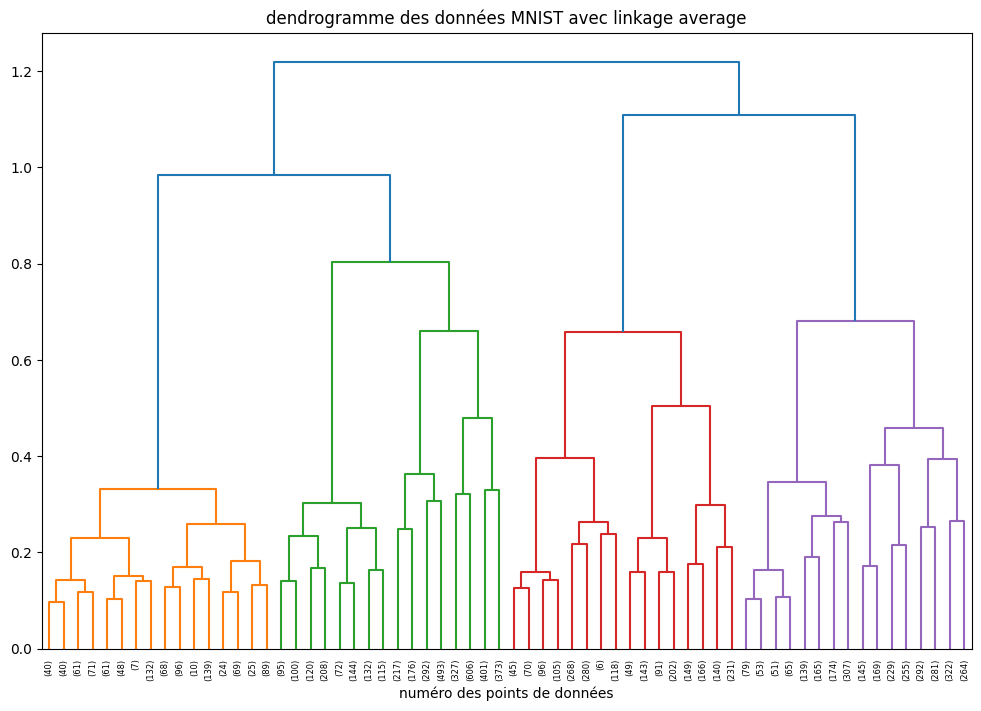

In [151]:
mnist_X = pd.read_csv("../MNIST-20260105/mnist_data.csv")/100
mnist_y = pd.read_csv("../MNIST-20260105/mnist_labels.csv",dtype=int).squeeze()

model = AgglomerativeClustering(n_clusters=10, linkage='average', compute_distances=True)

model = model.fit(mnist_X)
plt.title("dendrogramme des données MNIST avec linkage average")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=5)
plt.xlabel("numéro des points de données")
plt.show()

## Données députés

Nous allons maintenant travailler sur les données députés.

In [152]:
deputes = pd.read_csv('deputes.csv',delimiter=';')
deputes

,id,nom,nom_de_famille,prenom,sexe,date_naissance,lieu_naissance,num_deptmt,nom_circo,num_circo,...,hemicycle_interventions,hemicycle_interventions_courtes,amendements_proposes,amendements_signes,amendements_adoptes,rapports,propositions_ecrites,propositions_signees,questions_ecrites,questions_orales
0,32,Damien Abad,Abad,Damien,H,1980-04-05,Nîmes (Gard),01,Ain,5,...,160,219,4,1315,42,0,4,68,52,8
1,43,Caroline Abadie,Abadie,Caroline,F,1976-09-07,Saint-Martin-d'Hères (Isère),38,Isère,8,...,15,7,22,403,237,0,0,10,2,1
2,493,Jean-Félix Acquaviva,Acquaviva,Jean-Félix,H,1973-03-19,Bastia (Haute-Corse),2B,Haute-Corse,2,...,120,7,189,2215,68,0,0,11,20,4
3,152,Lénaïck Adam,Adam,Lénaïck,H,1992-02-19,Saint Laurent du Maroni (Guyane),973,Guyane,2,...,6,1,44,606,261,1,2,14,2,0
4,234,Damien Adam,Adam,Damien,H,1989-06-28,Orléans (Loiret),76,Seine-Maritime,1,...,17,5,102,626,276,1,1,19,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,215,Hubert Wulfranc,Wulfranc,Hubert,H,1956-12-17,Rouen (Seine-Maritime),76,Seine-Maritime,3,...,124,51,61,1833,76,0,3,40,33,14
535,130,Hélène Zannier,Zannier,Hélène,F,1972-09-19,Saint-Avold (Moselle),57,Moselle,7,...,8,1,10,559,275,0,0,18,21,1
536,614,Souad Zitouni,Zitouni,Souad,F,1974-04-23,Boukadir (Algérie),84,Vaucluse,1,...,23,8,114,951,274,0,0,18,4,1
537,31,Jean-Marc Zulesi,Zulesi,Jean-Marc,H,1988-06-06,Marseille (Bouches-du-Rhône),13,Bouches-du-Rhône,8,...,21,12,128,1045,351,2,0,19,42,2


In [153]:
deputes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               539 non-null    int64  
 1   nom                              539 non-null    object 
 2   nom_de_famille                   539 non-null    object 
 3   prenom                           539 non-null    object 
 4   sexe                             539 non-null    object 
 5   date_naissance                   539 non-null    object 
 6   lieu_naissance                   539 non-null    object 
 7   num_deptmt                       539 non-null    object 
 8   nom_circo                        539 non-null    object 
 9   num_circo                        539 non-null    int64  
 10  mandat_debut                     539 non-null    object 
 11  mandat_fin                       0 non-null      float64
 12  ancien_depute         

In [154]:
dim_activite = ["semaines_presence","commission_presences","commission_interventions","hemicycle_interventions","hemicycle_interventions_courtes","amendements_proposes","amendements_signes","amendements_adoptes","rapports","propositions_ecrites","propositions_signees","questions_ecrites","questions_orales"]

#### 7. Sélectionnez les données qui correspondent aux activités des députés dans l'hémicycle, c'est à dire les colonnes indiquées dans la variable `dim_activite`.  Vous pouvez ajouter d'autres colonnes si cela vous semble pertinent.

In [155]:
deputes_activite = deputes[dim_activite]
deputes_activite.head()

,semaines_presence,commission_presences,commission_interventions,hemicycle_interventions,hemicycle_interventions_courtes,amendements_proposes,amendements_signes,amendements_adoptes,rapports,propositions_ecrites,propositions_signees,questions_ecrites,questions_orales
0,41,46,3,160,219,4,1315,42,0,4,68,52,8
1,25,26,4,15,7,22,403,237,0,0,10,2,1
2,20,5,0,120,7,189,2215,68,0,0,11,20,4
3,12,5,1,6,1,44,606,261,1,2,14,2,0
4,18,28,0,17,5,102,626,276,1,1,19,13,1


#### 8. Utilisez la méthode de prétraitement `sklearn.preprocessing.StandardScaler` avec les paramètres par défaut pour normaliser les données. Que fait cette fonction de prétraitement ?

In [156]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
deputes_activite_scaled = scaler.fit_transform(deputes_activite)
deputes_activite_scaled = pd.DataFrame(deputes_activite_scaled,columns=dim_activite)
deputes_activite_scaled.head()


,semaines_presence,commission_presences,commission_interventions,hemicycle_interventions,hemicycle_interventions_courtes,amendements_proposes,amendements_signes,amendements_adoptes,rapports,propositions_ecrites,propositions_signees,questions_ecrites,questions_orales
0,2.333293,2.608601,-0.001919,0.273922,0.118079,-0.593270,-0.014626,-1.325802,-0.574866,1.340766,1.175596,2.036624,2.065937
1,0.236563,0.920074,0.071953,-0.388303,-0.181226,-0.484487,-0.797899,0.590694,-0.574866,-0.455811,-0.613407,-0.883209,-0.577257
2,-0.418665,-0.852878,-0.223534,0.091240,-0.181226,0.524773,0.758340,-1.070269,-0.574866,-0.455811,-0.582562,0.167931,0.555540
3,-1.467031,-0.852878,-0.149662,-0.429406,-0.189697,-0.351531,-0.623552,0.826570,0.048580,0.442478,-0.490027,-0.883209,-0.954856
4,-0.680757,1.088927,-0.223534,-0.379168,-0.184050,-0.001009,-0.606375,0.973993,0.048580,-0.006666,-0.335803,-0.240846,-0.577257


La fonction StandardScaler permet de mettre toutes variables de la base dans une meme échelle. Elle centre et réduit les variables afin d’éviter qu’une dimension domine le calcul des distances, ce qui est essentiel pour le CAH basé sur la distance.

#### 9. Utiliser la dissimilarité  `ward linkage` qui a pour objectif, comme les k-moyennes, de minimiser la variance intra classe des différents groupes. Affichez le dendrogramme que l'on obtient sur les données des députés lorsque l'on effectue un partitionnement hiérarchique avec cette méthode. Combien de groupes le dendrogramme suggère-t-il de sélectionner ?

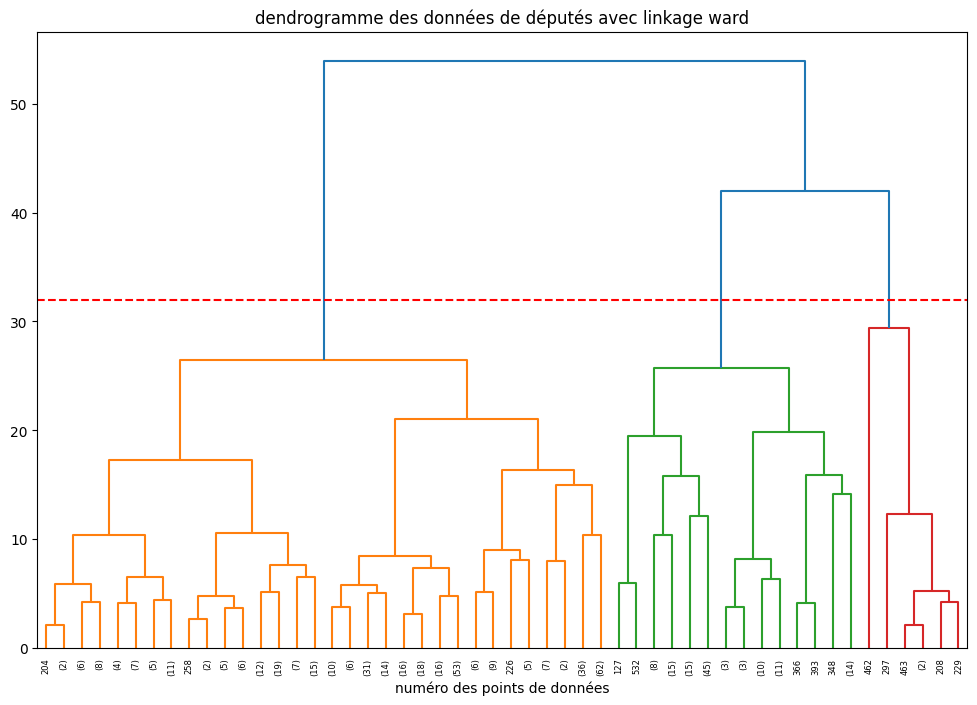

In [157]:
model = AgglomerativeClustering(linkage='ward', compute_distances=True)

model = model.fit(deputes_activite_scaled)
plt.title("dendrogramme des données de députés avec linkage ward")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=5)
# tracé d'une ligne horizontale pour couper le dendrogramme
plt.axhline(y=32, color='r', linestyle='--')
plt.xlabel("numéro des points de données")
plt.show()

D'après le tracé, nous constatons que le dendrogramme suggère une répartition des individus en trois groupes.

#### 10. Apprenez un nouveau modèle pour séparer les données en 2 groupes.

Ici j'ai appel à un ACP pour pouvoir représenter les segmentation dans le plan vu que la dimension de départ était égale à 13.

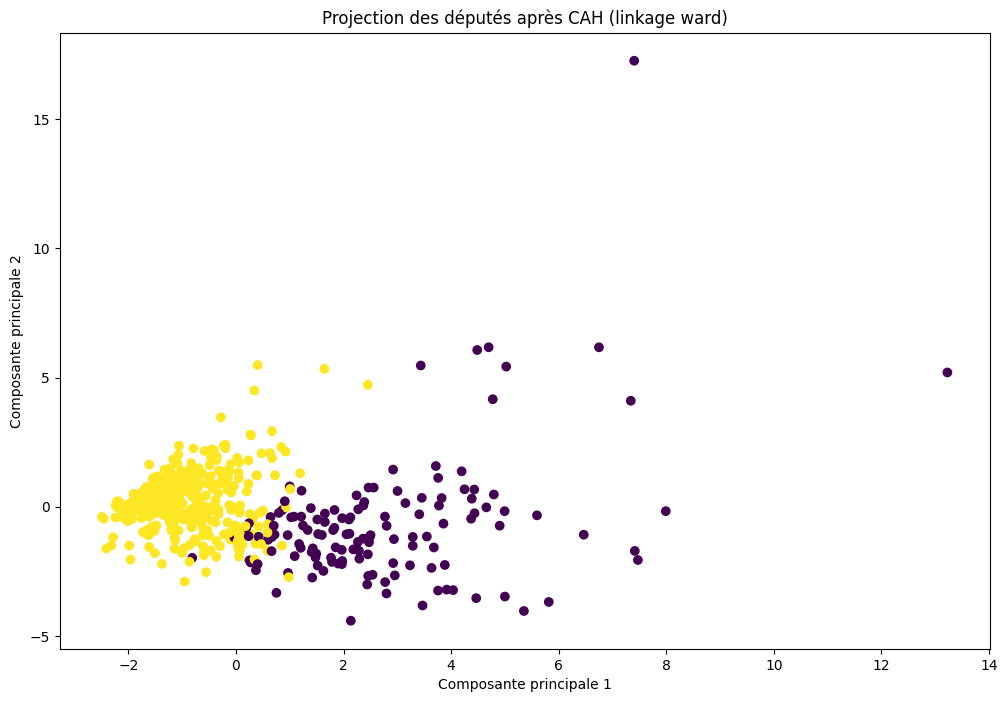

In [158]:
mod_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
mod_ward_labels = mod_ward.fit_predict(deputes_activite_scaled)

from sklearn.decomposition import PCA
pca = PCA(n_components=2) # je veux projeter sur 2 dimensions

# Projection des individus
deputes_pca = pca.fit_transform(deputes_activite_scaled) # on utilise les données standardisées
deputes_pca = pd.DataFrame(deputes_pca, columns=["axe1", "axe2"]) # je crée un DataFrame pour plus de facilité

plt.scatter(deputes_pca["axe1"], deputes_pca["axe2"], c=mod_ward_labels) # on colorie selon les clusters trouvés
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection des députés après CAH (linkage ward)")
plt.show()



Le code suivant permet d'afficher la matrice de contingence entre la colonne `parti_ratt_financier` et la colonne `groupe_sigle` des données députés.

In [159]:
from sklearn.metrics.cluster import contingency_matrix
deputes_sigle,deputes_sigle_inv = np.unique(deputes["groupe_sigle"],return_inverse=True)
deputes_finance,deputes_finance_inv = np.unique(deputes["parti_ratt_financier"],return_inverse=True)
pd.DataFrame(contingency_matrix(deputes_sigle_inv,deputes_finance_inv),columns=deputes_finance,index=deputes_sigle)

,Calédonie Ensemble,Cap sur l'avenir,Debout la France,Europe Écologie Les Verts,La France Insoumise,La République en Marche,Les Républicains,Mouvement Démocrate,Non déclaré(s),Non rattachée,Parti communiste français,Parti progressiste martiniquais,Parti radical de gauche,Parti socialiste,Rassemblement national,Régions et peuples solidaires,Tapura Huiraatira,Tavini Huiraatira No Te Ao Maohi - Front de libération de Polynésie,"Union des démocrates, radicaux et libéraux"
AE,0,0,0,0,0,5,0,12,0,1,0,0,0,0,0,0,1,0,1
GDR,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,1,0
LFI,0,0,0,0,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0
LR,0,0,0,0,0,0,90,0,0,0,0,0,0,0,0,0,0,0,1
LREM,0,1,0,0,0,258,0,0,0,0,0,0,0,0,0,0,0,0,1
LT,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,10,0,0,4
MODEM,0,0,0,0,0,0,0,52,0,0,0,0,0,0,0,1,0,0,2
NI,0,0,3,11,0,0,0,0,2,0,0,0,0,0,6,0,0,0,0
SOC,0,0,0,1,0,0,0,0,0,0,0,3,0,21,0,0,0,0,0
UDI,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,13


On y apprend par exemple que certains membres du groupe `LREM` à l'assemblée sont financés par des partis autres que `La République en Marche`. De la même façon, un des députés financé par `Les Républicains` fait parti du groupe `UDI` à l'assemblée.

#### 11. Utilisez la même approche pour étudier les liens entre les 2 groupes que vous avez obtenus et les `groupe_sigle` à l'assemblée. Que constatez-vous ?

In [160]:
# Encodage des groupes parlementaires
groupes, groupes_inv = np.unique(
    deputes["groupe_sigle"], # les valeurs à encoder 
    return_inverse=True # on veut l'inverse pour chaque député
)

# Matrice de contingence
table_clusters_groupes = pd.DataFrame(
    contingency_matrix(mod_ward_labels, groupes_inv), # les lignes sont les clusters, les colonnes les groupes parlementaires
    index=np.unique(mod_ward_labels), # les noms des lignes sont les numéros des clusters
    columns=groupes # les noms des colonnes sont les groupes parlementaires
)

table_clusters_groupes


,AE,GDR,LFI,LR,LREM,LT,MODEM,NI,SOC,UDI
0,7,12,15,58,3,7,3,4,18,9
1,13,3,2,33,257,11,52,18,7,7


Les clusters obtenus ne recouvrent pas directement les groupes parlementaires, mais mettent en évidence deux profils d’activité distincts : l’un majoritairement composé de députés LREM et MODEM, l’autre plus hétérogène sur le plan politique.

# Partie II : ACM

In [161]:
# Import des bibliothèques nécessaires
import prince

In [162]:
poison = pd.read_csv('poison.csv',delimiter=',')
poison.head(20)

,Age,Time,Sick,Sex,Nausea,Vomiting,Abdominals,Fever,Diarrhae,Potato,Fish,Mayo,Courgette,Cheese,Icecream
0,9,22,Sick_y,F,Nausea_y,Vomit_n,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
1,5,0,Sick_n,F,Nausea_n,Vomit_n,Abdo_n,Fever_n,Diarrhea_n,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_n,Icecream_y
2,6,16,Sick_y,F,Nausea_n,Vomit_y,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
3,9,0,Sick_n,F,Nausea_n,Vomit_n,Abdo_n,Fever_n,Diarrhea_n,Potato_y,Fish_y,Mayo_n,Courg_y,Cheese_y,Icecream_y
4,7,14,Sick_y,M,Nausea_n,Vomit_y,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
5,72,9,Sick_y,M,Nausea_n,Vomit_n,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_n,Mayo_y,Courg_y,Cheese_y,Icecream_y
6,5,16,Sick_y,F,Nausea_n,Vomit_y,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
7,10,8,Sick_y,F,Nausea_y,Vomit_y,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
8,5,20,Sick_y,M,Nausea_y,Vomit_n,Abdo_y,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y
9,11,12,Sick_y,M,Nausea_n,Vomit_y,Abdo_n,Fever_y,Diarrhea_y,Potato_y,Fish_y,Mayo_y,Courg_y,Cheese_y,Icecream_y


In [163]:
# Récupération des données actives 
X_actifs = poison.iloc[0:55, 4:15]

# Variables supplémentaires
X_quanti_sup = poison.iloc[0:55, [0, 1]]   # Age et Time
X_quali_sup = poison.iloc[0:55, [2, 3]]    # Maladie et Sexe

### 1. Réalisation de l’ACM (table disjonctive complète)

In [164]:
mca = prince.MCA(
    n_components=10,
    n_iter=10,
    random_state=42
)

mca = mca.fit(X_actifs)


### 2. Valeurs propres et choix du nombre d’axes

In [165]:
# Valeurs propres
eigenvalues = mca.eigenvalues_

# Pourcentage d'inertie
inertia = eigenvalues / eigenvalues.sum() * 100
inertia_cum = inertia.cumsum()

# Tableau récapitulatif
eig_table = pd.DataFrame({
    "Valeur propre": eigenvalues,
    "% inertie": inertia,
    "% inertie cumulée": inertia_cum
})

print(eig_table)


   Valeur propre  % inertie  % inertie cumulée
0       0.335231  33.940337          33.940337
1       0.129140  13.074694          47.015032
2       0.107348  10.868444          57.883476
3       0.095880   9.707273          67.590749
4       0.078833   7.981384          75.572133
5       0.071090   7.197452          82.769585
6       0.060166   6.091457          88.861043
7       0.055773   5.646711          94.507753
8       0.041206   4.171858          98.679611
9       0.013042   1.320389         100.000000


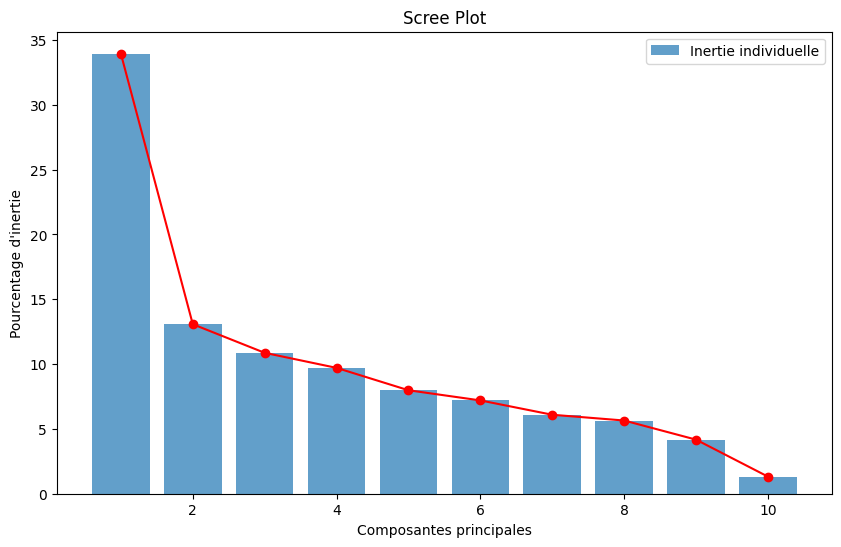

In [166]:
# Tracé du scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(eigenvalues) + 1), inertia, alpha=0.7, label='Inertie individuelle')
plt.plot(range(1, len(eigenvalues) + 1), inertia, color='red', marker='o')
plt.xlabel('Composantes principales')
plt.ylabel('Pourcentage d\'inertie')
plt.title('Scree Plot')
plt.legend()
plt.show()

Le choix des axes retenus se fait en fonction de l’inertie cumulée. Les deux premiers axes n’expliquent que 47 % de l’inertie totale, ce qui est insuffisant pour résumer correctement l’information.
Ainsi, les trois premiers axes ont été retenus, capturant environ 57.88 % de l’inertie et permettant une interprétation satisfaisante des relations entre les variables.

### 3. Représentation graphique des individus sur le plan factoriel

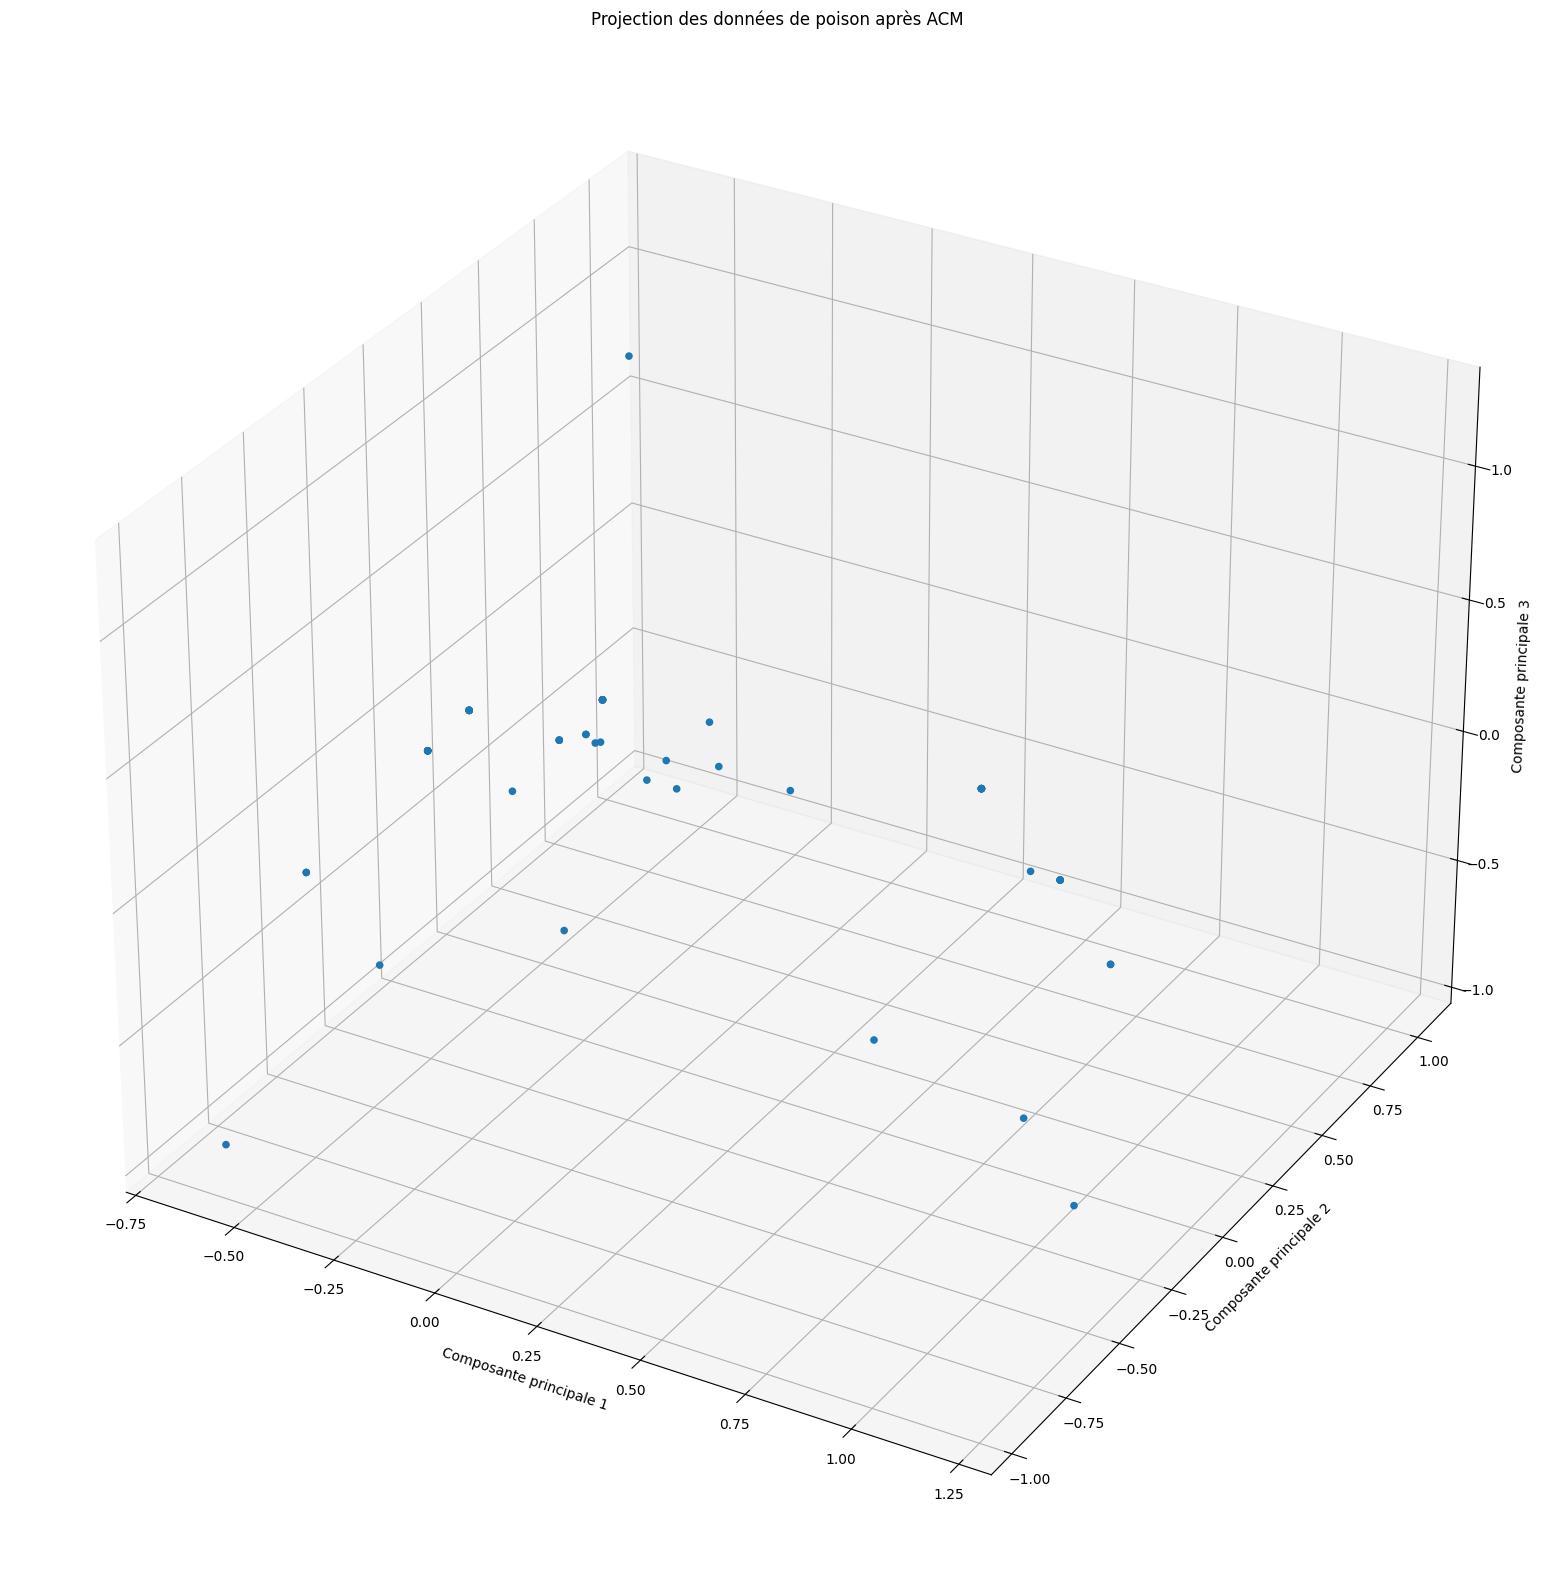

In [167]:
# Plot
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('axe1')
ax.set_ylabel('axe2')
ax.set_zlabel('axe3')


ax.scatter(
    coodonnees_individus[0], coodonnees_individus[1], coodonnees_individus[2],
    alpha=1
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")
plt.title("Projection des données de poison après ACM ")
plt.show()

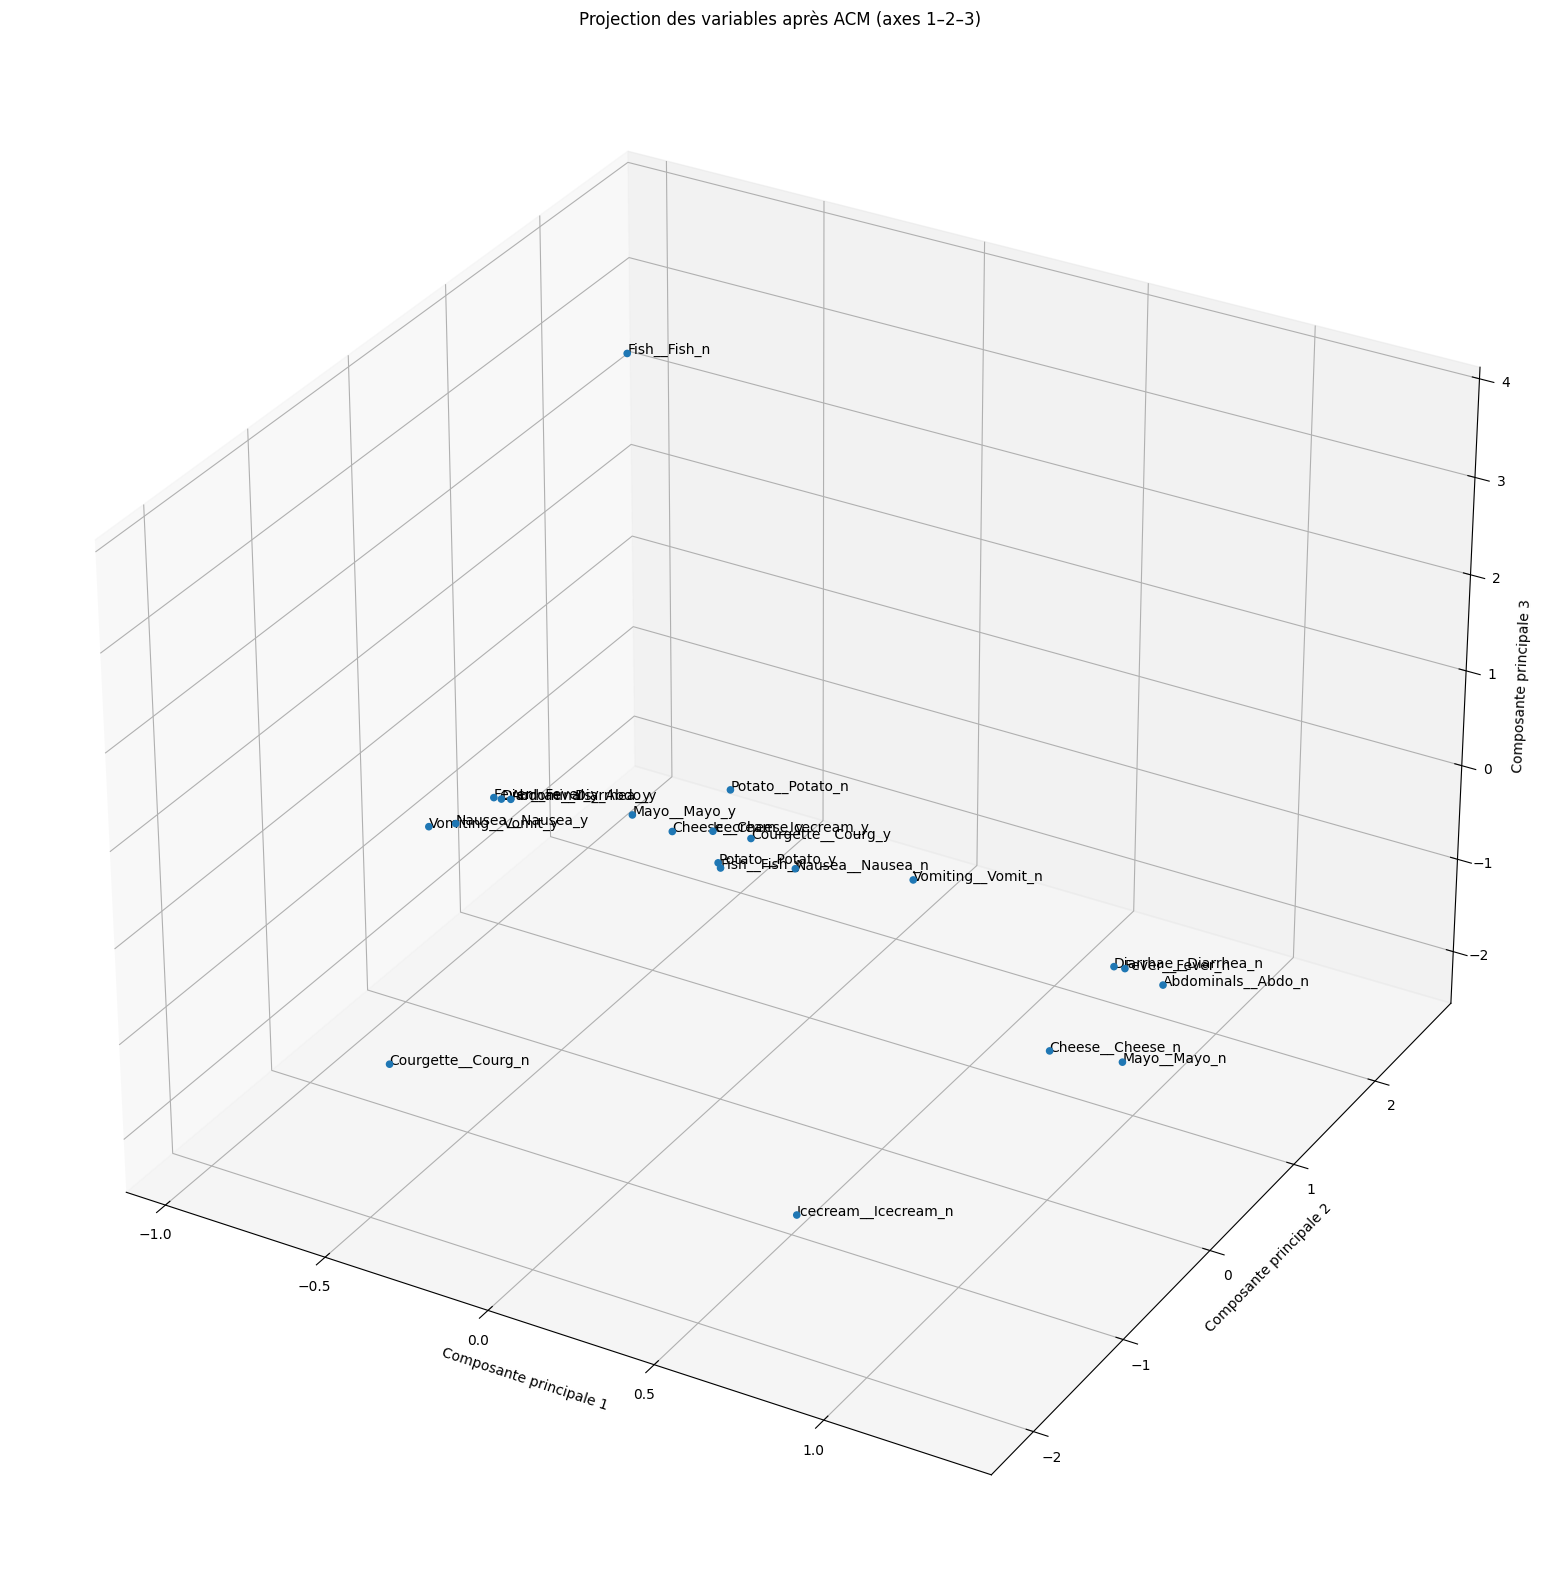

In [168]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Création de la figure 3D
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

# Labels des axes
ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")

# Nuage de points (coordonnées des variables)
ax.scatter(
    coordonnees_variables.iloc[:, 0],
    coordonnees_variables.iloc[:, 1],
    coordonnees_variables.iloc[:, 2],
    alpha=1
)

# Ajout des noms des variables (ANNOTATIONS 3D)
for i, txt in enumerate(coordonnees_variables.index):
    ax.text(
        coordonnees_variables.iloc[i, 0],
        coordonnees_variables.iloc[i, 1],
        coordonnees_variables.iloc[i, 2],
        txt,
        size=10,
        zorder=1,
        color='k'
    )

# Titre
plt.title("Projection des variables après ACM (axes 1–2–3)")
plt.show()


### 4. Résumez les résultats obtenus dans ces plans factoriels.

Sur l’axe 1, on observe une association forte entre des symptômes sévères tels que Vomiting, Abdominals, Diarrhea et Abdo, et les modalités alimentaires liées à la consommation de Mayonnaise.Cet axe met ainsi en évidence une relation entre la gravité des symptômes et certains aliments consommés, sans pour autant établir de lien de causalité.
L’axe 2 met en relation principalement les modalités alimentaires Cheese, Icecream et Courgette, suggérant des profils alimentaires distincts indépendamment de la gravité des symptômes.
L’axe 3 permet d’affiner l’interprétation en distinguant des modalités proches dans le plan factoriel formé par les axes 1 et 2, mais séparées selon la troisième dimension. Certaines modalités alimentaires, telles que Icecream et Courgette, apparaissent relativement isolées sur cet axe.
Ainsi, l’axe 3 apporte une information complémentaire permettant de mieux différencier des profils d’intoxication proches mais non identiques.

### 5. ACM à partir de la table de Burt

In [169]:
mca_burt = prince.MCA(
    n_components=10,
    n_iter=10,
    random_state=42
).fit(X_actifs)


In [170]:
comparison = pd.DataFrame({
    "ACM_disjonctif": mca.eigenvalues_,
    "ACM_Burt": mca_burt.eigenvalues_,
    "difference": mca.eigenvalues_ - mca_burt.eigenvalues_
})

print(comparison)



   ACM_disjonctif  ACM_Burt  difference
0        0.335231  0.335231         0.0
1        0.129140  0.129140         0.0
2        0.107348  0.107348         0.0
3        0.095880  0.095880         0.0
4        0.078833  0.078833         0.0
5        0.071090  0.071090         0.0
6        0.060166  0.060166         0.0
7        0.055773  0.055773         0.0
8        0.041206  0.041206         0.0
9        0.013042  0.013042         0.0


In [171]:
coordonnees_variables_burt = mca_burt.column_coordinates(X_actifs)

comparison_coord = pd.DataFrame({
    "ACM_disjonctif_axe1": coordonnees_variables[0],
    "ACM_disjonctif_axe2": coordonnees_variables[1],
    "ACM_disjonctif_axe3": coordonnees_variables[2],
    "ACM_Burt_axe1": coordonnees_variables_burt[0],
    "ACM_Burt_axe2": coordonnees_variables_burt[1],
    "ACM_Burt_axe3": coordonnees_variables_burt[2],
    "difference_axe1": coordonnees_variables[0] - coordonnees_variables_burt[0],
    "difference_axe2": coordonnees_variables[1] - coordonnees_variables_burt[1],
    "difference_axe3": coordonnees_variables[2] - coordonnees_variables_burt[2]
})
comparison_coord

,ACM_disjonctif_axe1,ACM_disjonctif_axe2,ACM_disjonctif_axe3,ACM_Burt_axe1,ACM_Burt_axe2,ACM_Burt_axe3,difference_axe1,difference_axe2,difference_axe3
Nausea__Nausea_n,0.267391,-0.121390,0.265583,0.267391,-0.121390,0.265583,0.0,0.0,0.0
Nausea__Nausea_y,-0.958151,0.434982,-0.951673,-0.958151,0.434982,-0.951673,0.0,0.0,0.0
Vomiting__Vomit_n,0.479028,0.409195,-0.084493,0.479028,0.409195,-0.084493,0.0,0.0,0.0
Vomiting__Vomit_y,-0.718542,-0.613792,0.126739,-0.718542,-0.613792,0.126739,0.0,0.0,0.0
Abdominals__Abdo_n,1.318022,0.035745,0.005094,1.318022,0.035745,0.005094,0.0,0.0,0.0
Abdominals__Abdo_y,-0.641200,-0.017389,-0.002478,-0.641200,-0.017389,-0.002478,0.0,0.0,0.0
Fever__Fever_n,1.171831,0.174895,-0.097275,1.171831,0.174895,-0.097275,0.0,0.0,0.0
Fever__Fever_y,-0.669618,-0.099940,0.055586,-0.669618,-0.099940,0.055586,0.0,0.0,0.0
Diarrhae__Diarrhea_n,1.182822,0.002757,0.082980,1.182822,0.002757,0.082980,0.0,0.0,0.0
Diarrhae__Diarrhea_y,-0.675899,-0.001575,-0.047417,-0.675899,-0.001575,-0.047417,0.0,0.0,0.0


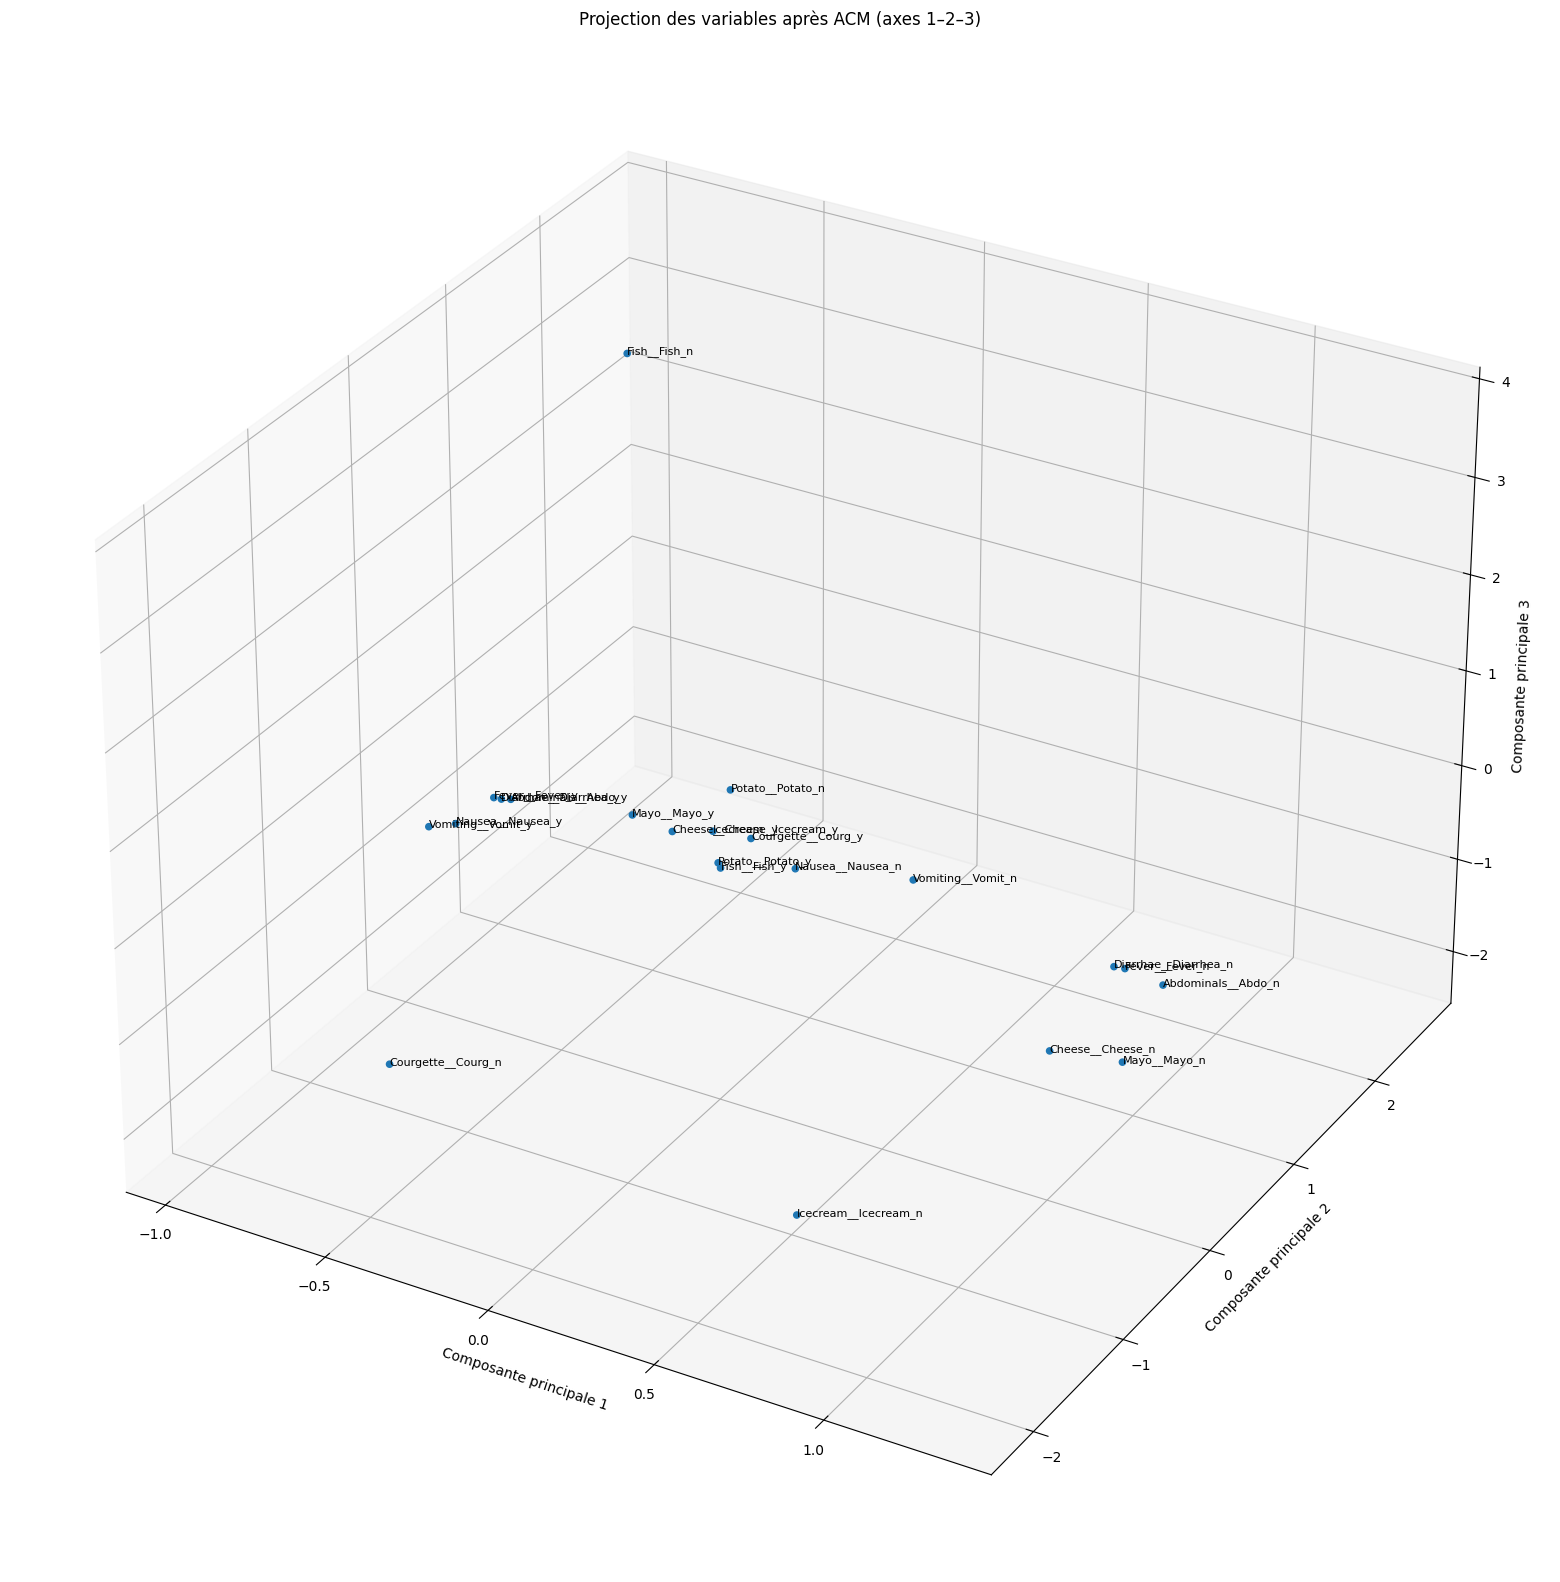

In [172]:
# Création de la figure 3D
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

# Labels des axes
ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")

# Nuage de points (coordonnées des variables)
ax.scatter(
    coordonnees_variables_burt.iloc[:, 0],
    coordonnees_variables_burt.iloc[:, 1],
    coordonnees_variables_burt.iloc[:, 2],
    alpha=1
)

# Ajout des noms des variables (ANNOTATIONS 3D)
for i, txt in enumerate(coordonnees_variables_burt.index):
    ax.text(
        coordonnees_variables_burt.iloc[i, 0],
        coordonnees_variables_burt.iloc[i, 1],
        coordonnees_variables_burt.iloc[i, 2],
        txt,
        size=8
    )

# Titre
plt.title("Projection des variables après ACM (axes 1–2–3)")
plt.show()



Les valeurs propres obtenues à partir de la table disjonctive complète et de la table de Burt sont identiques.
Ceci est conforme à la théorie de l’Analyse des Correspondances Multiples : les deux méthodes conduisent aux mêmes axes factoriels, la différence portant uniquement sur l’échelle de l’inertie. L’ACM sur la table disjonctive est cependant préférable, car l’ACM sur la table de Burt tend à surestimer l’inertie.

## Partie III : ACM MIXTE

In [173]:
from prince import FAMD

# Conversion explicite en float
poison["Age"] = poison["Age"].astype(float)
poison["Time"] = poison["Time"].astype(float)



# Analyse en Correspondances Mixte (variables quantitatives + qualitatives)
mixte_acm = FAMD(
    n_components=5,     # Nombre d'axes factoriels calculés
    random_state=42     # Reproductibilité
)

# Ajustement du modèle sur l'ensemble des variables
mixte_acm = mixte_acm.fit(poison)

# Coordonnées factorielles des individus
# Ces coordonnées seront utilisées pour la représentation graphique
# et pour le clustering
mixte_acm_coords = mixte_acm.transform(poison)
print(mixte_acm_coords.head(20))

component         0         1          2          3         4
0         -4.280661 -1.040060  -2.779355  -0.361700 -2.712331
1          8.175141  0.555681  -0.396343  -1.205217 -1.678108
2         -4.213598  1.733784   0.931021  -2.005778 -2.216575
3          8.513872  0.025511  -0.644736  -0.926810 -1.545756
4         -4.256311  0.072263   2.498242  -1.138276  1.705968
5         -3.531565 -6.112639  11.523336  12.124267 -4.435509
6         -4.213541  1.734443   0.926861  -2.008205 -2.213704
7         -5.387069  0.905166  -1.978166  -1.876936 -1.380619
8         -4.323086 -2.698288  -1.232932   0.493667  1.224569
9         -1.865340 -0.064632   2.561538  -1.560925  2.058334
10        -5.569146  0.891802  -1.984127  -1.917759 -1.393567
11         0.178170  1.234743   0.709116  -3.445647 -1.708167
12        -2.886225 -0.213112   0.250818  -0.374311 -3.610946
13         8.513872  0.025511  -0.644736  -0.926810 -1.545756
14         9.905757 -0.149841   0.729753   1.320779  3.107907
15      

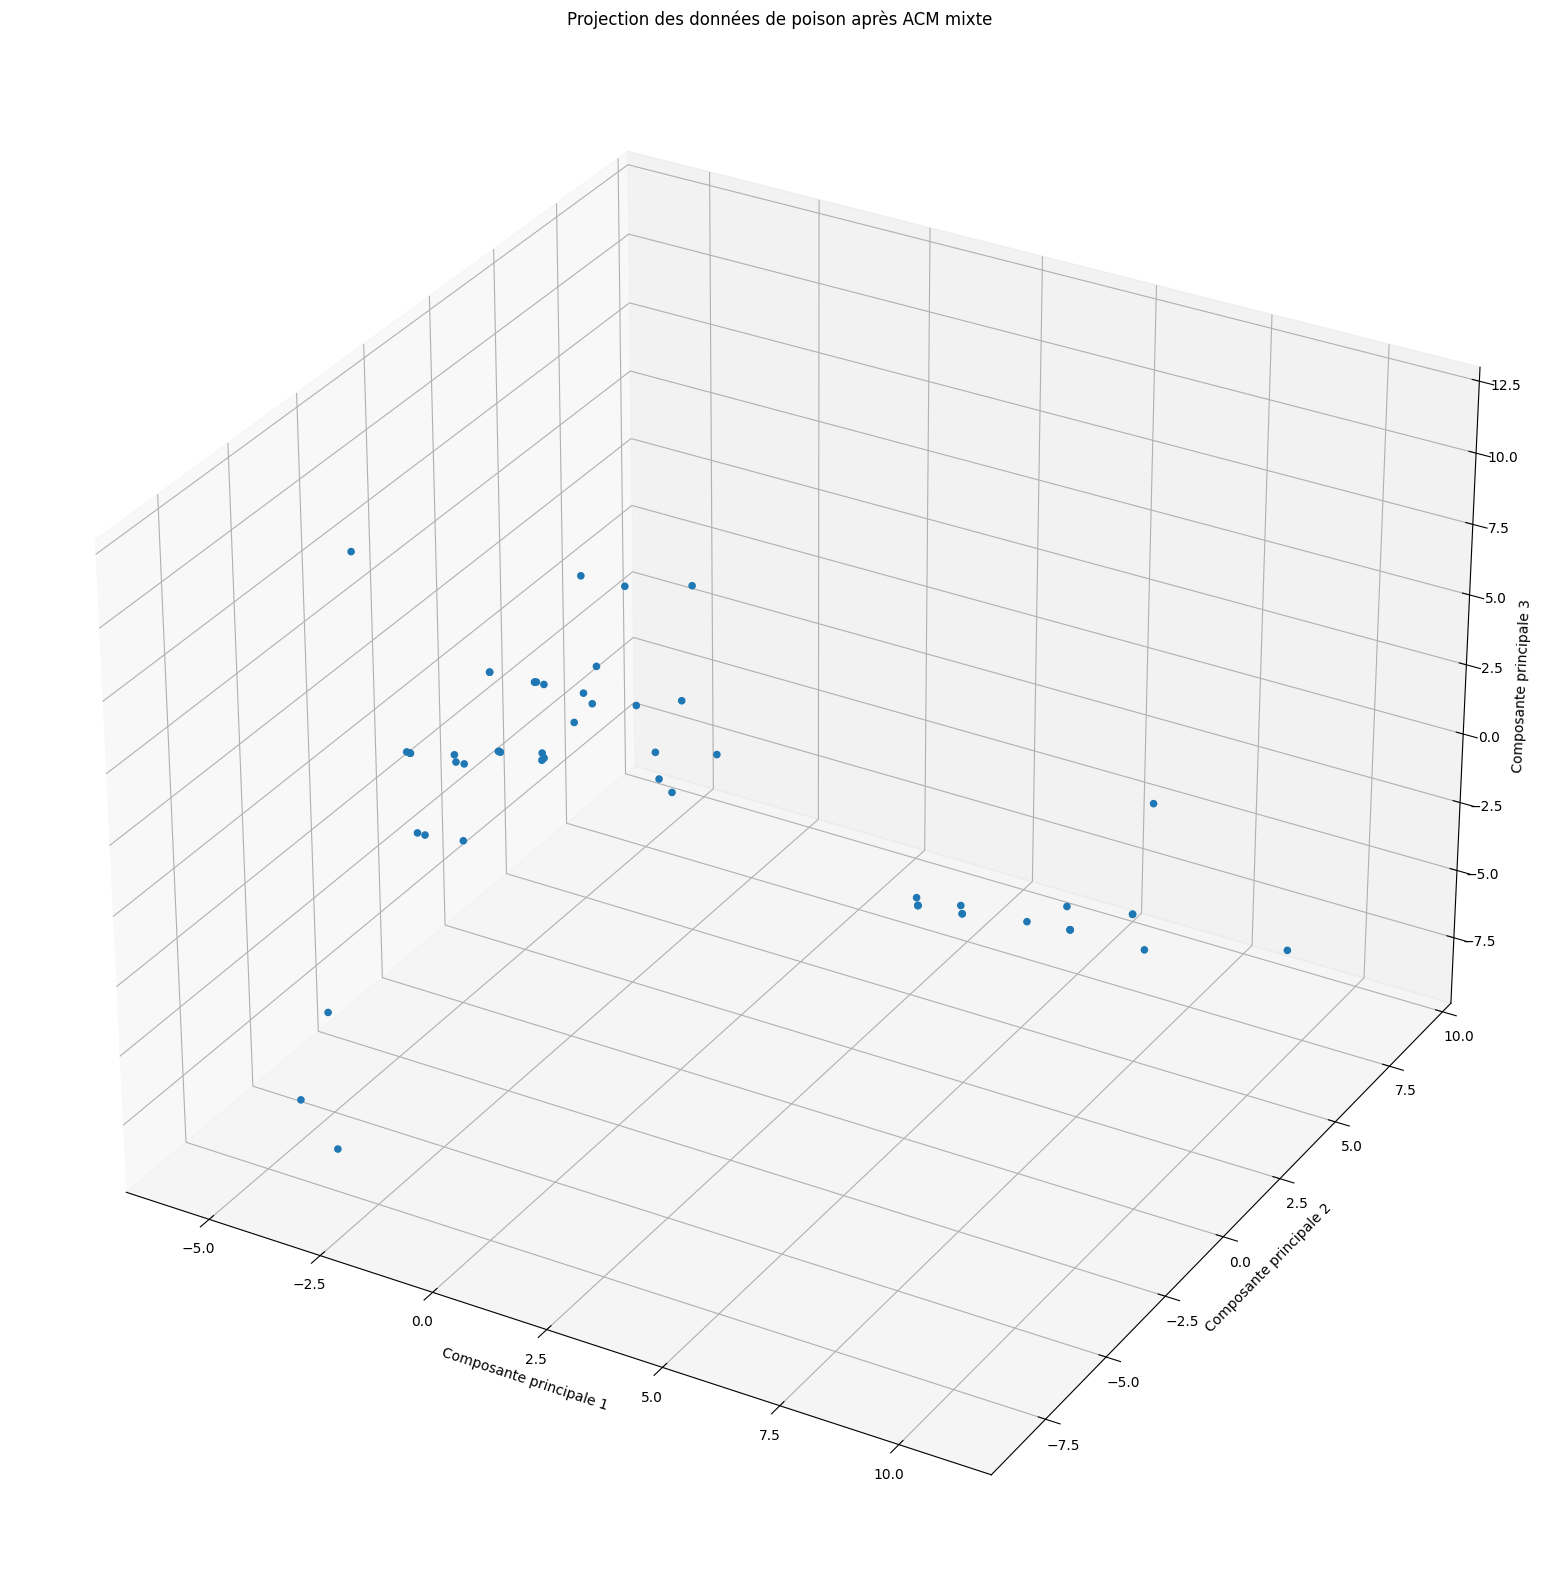

In [174]:
# Plot
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('axe1')
ax.set_ylabel('axe2')
ax.set_zlabel('axe3')


ax.scatter(
    mixte_acm_coords[0], mixte_acm_coords[1], mixte_acm_coords[2],
    alpha=1
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")
plt.title("Projection des données de poison après ACM mixte")
plt.show()

### Partie IV : Clustering

In [175]:
from sklearn.cluster import AgglomerativeClustering, KMeans

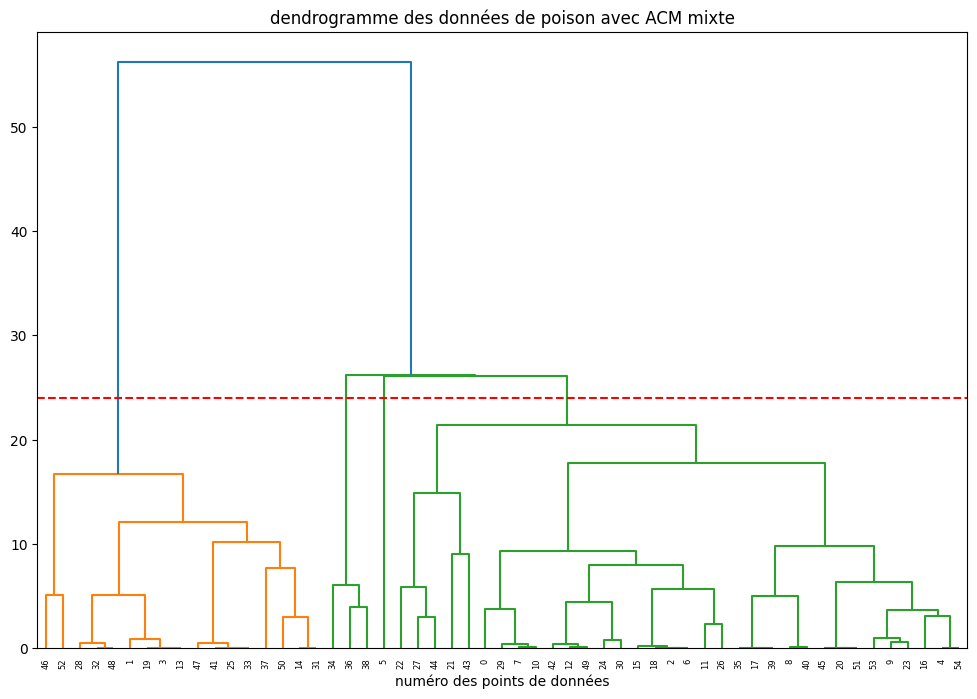

In [176]:
model_cah = AgglomerativeClustering(compute_distances=True)

model_cah = model_cah.fit(mixte_acm_coords)
plt.title("dendrogramme des données de poison avec ACM mixte")
# plot the top three levels of the dendrogram
plot_dendrogram(model_cah, truncate_mode="level")
# tracé d'une ligne horizontale pour couper le dendrogramme
plt.axhline(y=24, color='r', linestyle='--')
plt.xlabel("numéro des points de données")
plt.show()

Le choix de quatre groupes a été effectué à partir du dendrogramme de la Classification Ascendante Hiérarchique appliquée aux coordonnées factorielles issues de l’ACM mixte.
La coupure de l’arbre à un niveau de distance d’environ 24 met en évidence une rupture nette dans les fusions successives, conduisant à quatre groupes bien distincts.
Ce choix permet d’obtenir des classes homogènes et interprétables, tout en évitant une sur-segmentation des données. Les groupes ainsi obtenus sont cohérents avec la structure révélée par l’ACM mixte et correspondent à des profils différenciés d’intoxication alimentaire.

##### Clustering CAH

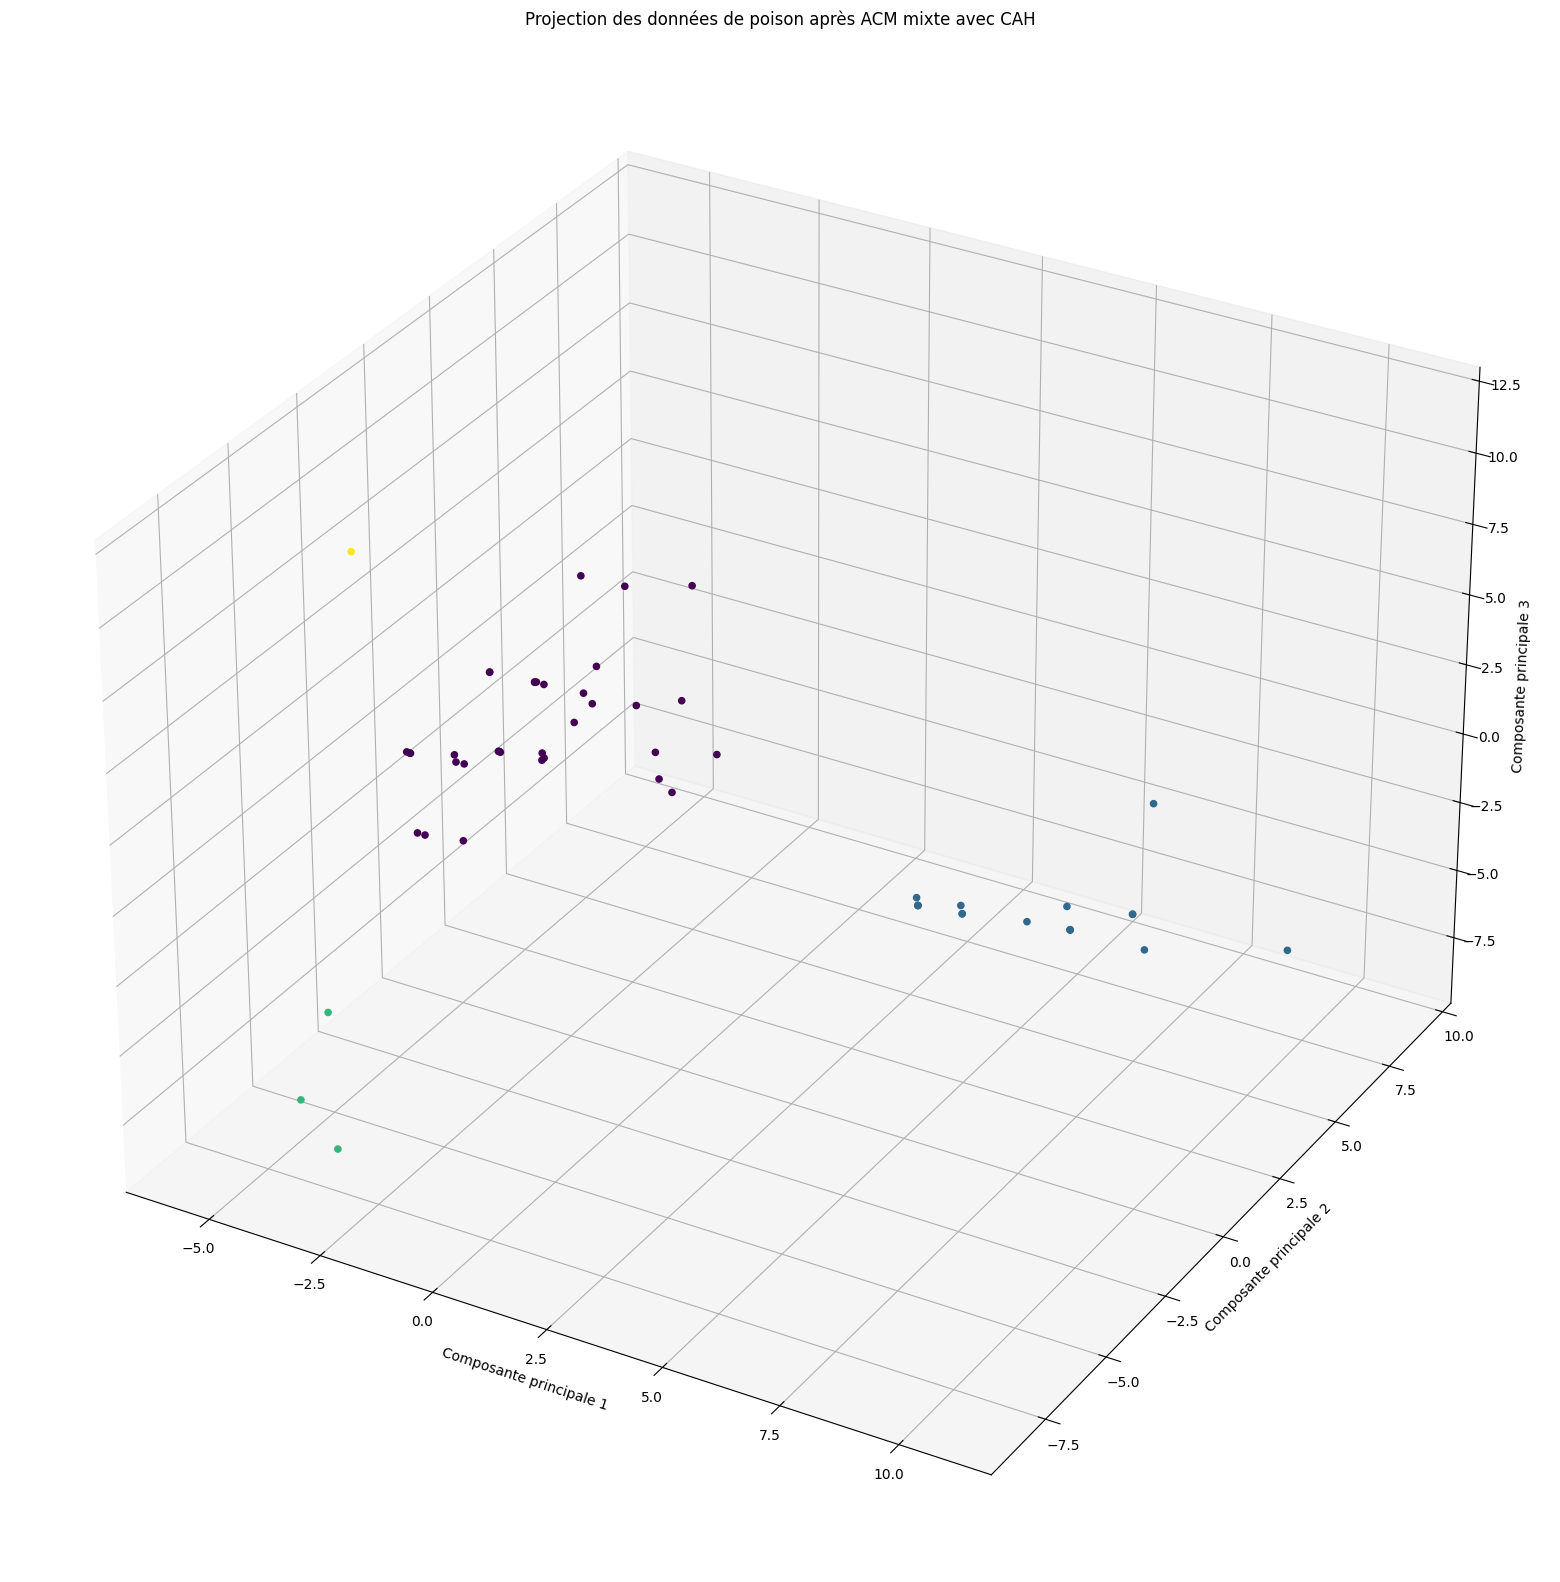

In [177]:
model_cah = AgglomerativeClustering(n_clusters=4)
model_cah_labels = model_cah.fit_predict(mixte_acm_coords)

# Plot
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('axe1')
ax.set_ylabel('axe2')
ax.set_zlabel('axe3')


ax.scatter(
    mixte_acm_coords[0], mixte_acm_coords[1], mixte_acm_coords[2],
    c=model_cah_labels,
    alpha=1
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")
plt.title("Projection des données de poison après ACM mixte avec CAH")
plt.show()

##### Clustering K-means

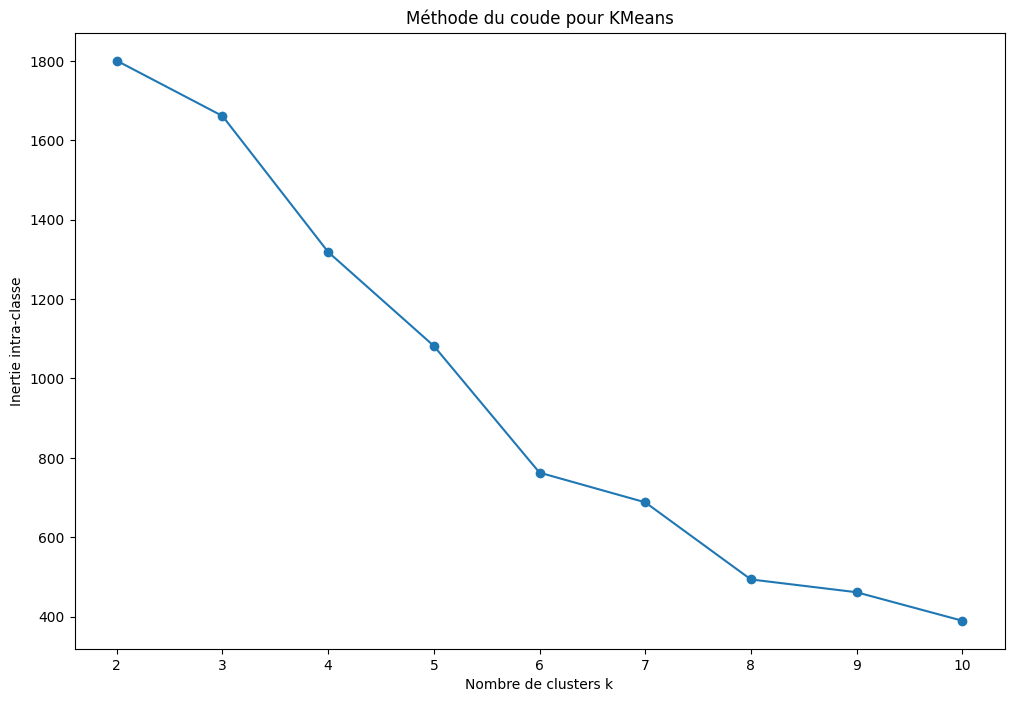

In [178]:
inertie_intra = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans = kmeans.fit(mixte_acm_coords)
    inertie_intra.append(kmeans.inertia_)

plt.plot(K_range, inertie_intra, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-classe')
plt.title('Méthode du coude pour KMeans')
plt.show()

Je choisis k=4 car le graphique montre un coude net à cette valeur, indiquant que l’ajout de clusters supplémentaires n’améliore pas significativement la structure des groupes tout en maintenant une segmentation interprétable.

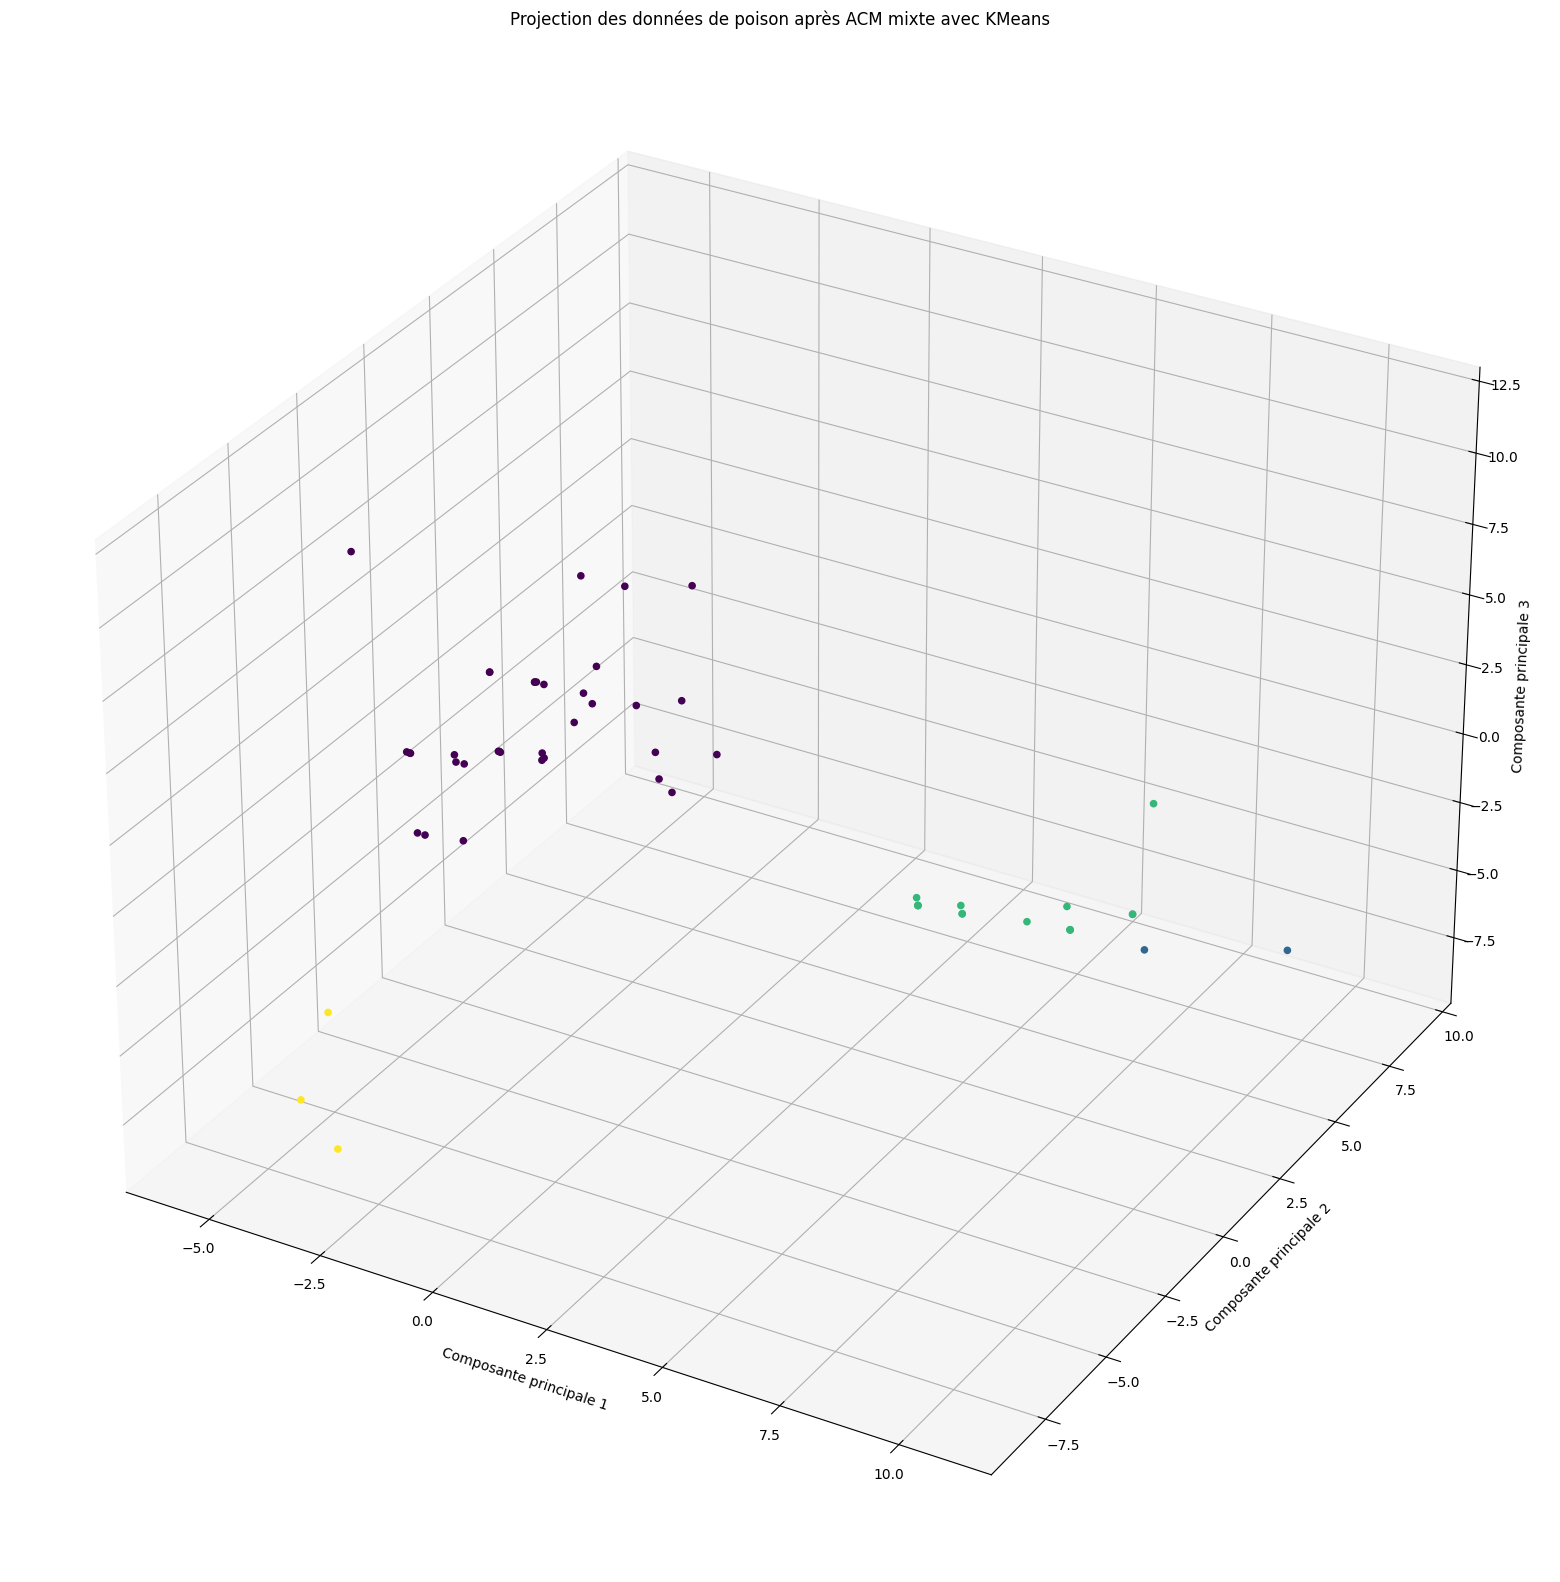

In [179]:
model_kmeans = KMeans(n_clusters=4, random_state=42)
model_kmeans_labels = model_kmeans.fit_predict(mixte_acm_coords)

# Plot
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('axe1')
ax.set_ylabel('axe2')
ax.set_zlabel('axe3')


ax.scatter(
    mixte_acm_coords[0], mixte_acm_coords[1], mixte_acm_coords[2],
    c=model_kmeans_labels,
    alpha=1
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
ax.set_zlabel("Composante principale 3")
plt.title("Projection des données de poison après ACM mixte avec KMeans")
plt.show()